<center><p float="center">
  <img src="https://upload.wikimedia.org/wikipedia/commons/e/e9/4_RGB_McCombs_School_Brand_Branded.png" width="300" height="100"/>
  <img src="https://mma.prnewswire.com/media/1458111/Great_Learning_Logo.jpg?p=facebook" width="200" height="100"/>
</p></center>

<center><font size=10>Data Science and Business Analytics</font></center>
<center><font size=6>Unsupervised Learning: Trade & Ahead</font></center>

<center><font size=6>By Joseph Anyanwu

<center><img src="
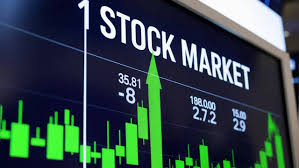" width="800" height="500"></center>


## Problem Statement

### Context

The stock market has consistently proven to be a good place to invest in and save for the future. There are a lot of compelling reasons to invest in stocks. It can help in fighting inflation, create wealth, and also provides some tax benefits. Good steady returns on investments over a long period of time can also grow a lot more than seems possible. Also, thanks to the power of compound interest, the earlier one starts investing, the larger the corpus one can have for retirement. Overall, investing in stocks can help meet life's financial aspirations.

It is important to maintain a diversified portfolio when investing in stocks in order to maximise earnings under any market condition. Having a diversified portfolio tends to yield higher returns and face lower risk by tempering potential losses when the market is down. It is often easy to get lost in a sea of financial metrics to analyze while determining the worth of a stock, and doing the same for a multitude of stocks to identify the right picks for an individual can be a tedious task. By doing a cluster analysis, one can identify stocks that exhibit similar characteristics and ones which exhibit minimum correlation. This will help investors better analyze stocks across different market segments and help protect against risks that could make the portfolio vulnerable to losses.


### Objective

Trade&Ahead is a financial consultancy firm who provide their customers with personalized investment strategies. They have hired you as a Data Scientist and provided you with data comprising stock price and some financial indicators for a few companies listed under the New York Stock Exchange. They have assigned you the tasks of analyzing the data, grouping the stocks based on the attributes provided, and sharing insights about the characteristics of each group.

### Data Dictionary

- Ticker Symbol: An abbreviation used to uniquely identify publicly traded shares of a particular stock on a particular stock market
- Company: Name of the company
- GICS Sector: The specific economic sector assigned to a company by the Global Industry Classification Standard (GICS) that best defines its business operations
- GICS Sub Industry: The specific sub-industry group assigned to a company by the Global Industry Classification Standard (GICS) that best defines its business operations
- Current Price: Current stock price in dollars
- Price Change: Percentage change in the stock price in 13 weeks
- Volatility: Standard deviation of the stock price over the past 13 weeks
- ROE: A measure of financial performance calculated by dividing net income by shareholders' equity (shareholders' equity is equal to a company's assets minus its debt)
- Cash Ratio: The ratio of a  company's total reserves of cash and cash equivalents to its total current liabilities
- Net Cash Flow: The difference between a company's cash inflows and outflows (in dollars)
- Net Income: Revenues minus expenses, interest, and taxes (in dollars)
- Earnings Per Share: Company's net profit divided by the number of common shares it has outstanding (in dollars)
- Estimated Shares Outstanding: Company's stock currently held by all its shareholders
- P/E Ratio: Ratio of the company's current stock price to the earnings per share
- P/B Ratio: Ratio of the company's stock price per share by its book value per share (book value of a company is the net difference between that company's total assets and total liabilities)

## Importing necessary libraries and data

In [ ]:
# Installing the libraries with the specified version.
# uncomment and run the following line if Google Colab is being used
# !pip install scikit-learn==1.2.2 seaborn==0.13.1 matplotlib==3.7.1 numpy==1.25.2 pandas==1.5.3 yellowbrick==1.5 -q --user

In [ ]:
# Installing the libraries with the specified version.
# uncomment and run the following lines if Jupyter Notebook is being used
# !pip install scikit-learn==1.2.2 seaborn==0.13.1 matplotlib==3.7.1 numpy==1.25.2 pandas==1.5.2 yellowbrick==1.5 -q --user
# !pip install --upgrade -q jinja2

**Note**: *After running the above cell, kindly restart the notebook kernel and run all cells sequentially from the start again.*

In [ ]:
# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# Libraries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='darkgrid')

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 200)

# to scale the data using z-score
from sklearn.preprocessing import StandardScaler

# to compute distances
from scipy.spatial.distance import cdist, pdist

# to perform k-means clustering and compute silhouette scores
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# to visualize the elbow curve and silhouette scores
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer

# to perform hierarchical clustering, compute cophenetic correlation, and create dendrograms
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage, cophenet

# to perform PCA
from sklearn.decomposition import PCA

# to suppress warnings
import warnings
warnings.filterwarnings("ignore")

## Reading the Dataset

In [ ]:
# loading the dataset
from google.colab import files
import io

# Upload the file manually
uploaded = files.upload()

# Automatically get the uploaded filename
filename = list(uploaded.keys())[0]  # Gets the first uploaded file

# Read the CSV file into a Pandas DataFrame
data = pd.read_csv(io.BytesIO(uploaded[filename]))

print(f"✅ File '{filename}' uploaded and read successfully!")
#data = pd.read_csv("data_add_nik.csv")

Saving stock_data.csv to stock_data.csv
✅ File 'stock_data.csv' uploaded and read successfully!


## Data Overview


### Checking the shape of the dataset

In [ ]:
data.shape

(340, 15)

There are 340 rows and 15 columns in the data

### Displaying a few rows of the data and Checking their data types

In [ ]:
# viewing a random sample of the dataset
data.sample(n=10, random_state=1)
# random_state=1 is used to ensure that the same random sample is selected every time the code is run

,Ticker Symbol,Security,GICS Sector,GICS Sub Industry,Current Price,Price Change,Volatility,ROE,Cash Ratio,Net Cash Flow,Net Income,Earnings Per Share,Estimated Shares Outstanding,P/E Ratio,P/B Ratio
102,DVN,Devon Energy Corp.,Energy,Oil & Gas Exploration & Production,32.000000,-15.478079,2.923698,205,70,830000000,-14454000000,-35.55,4.065823e+08,93.089287,1.785616
125,FB,Facebook,Information Technology,Internet Software & Services,104.660004,16.224320,1.320606,8,958,592000000,3669000000,1.31,2.800763e+09,79.893133,5.884467
11,AIV,Apartment Investment & Mgmt,Real Estate,REITs,40.029999,7.578608,1.163334,15,47,21818000,248710000,1.52,1.636250e+08,26.335526,-1.269332
248,PG,Procter & Gamble,Consumer Staples,Personal Products,79.410004,10.660538,0.806056,17,129,160383000,636056000,3.28,4.913916e+08,24.070121,-2.256747
238,OXY,Occidental Petroleum,Energy,Oil & Gas Exploration & Production,67.610001,0.865287,1.589520,32,64,-588000000,-7829000000,-10.23,7.652981e+08,93.089287,3.345102
336,YUM,Yum! Brands Inc,Consumer Discretionary,Restaurants,52.516175,-8.698917,1.478877,142,27,159000000,1293000000,2.97,4.353535e+08,17.682214,-3.838260
112,EQT,EQT Corporation,Energy,Oil & Gas Exploration & Production,52.130001,-21.253771,2.364883,2,201,523803000,85171000,0.56,1.520911e+08,93.089287,9.567952
147,HAL,Halliburton Co.,Energy,Oil & Gas Equipment & Services,34.040001,-5.101751,1.966062,4,189,7786000000,-671000000,-0.79,8.493671e+08,93.089287,17.345857
89,DFS,Discover Financial Services,Financials,Consumer Finance,53.619999,3.653584,1.159897,20,99,2288000000,2297000000,5.14,4.468872e+08,10.431906,-0.375934
173,IVZ,Invesco Ltd.,Financials,Asset Management & Custody Banks,33.480000,7.067477,1.580839,12,67,412000000,968100000,2.26,4.283628e+08,14.814159,4.218620


In [ ]:
# copying the data to another variable to avoid any changes to original data
df = data.copy()

### The Columns names are not suitable for coding, so we need to format them to replace space with underscore(_)

In [ ]:
# replacing spaces in column names with underscore(_)
df.columns = [c.replace(" ", "_") for c in df.columns]

In [ ]:
# checkin the data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 340 entries, 0 to 339
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticker_Symbol                 340 non-null    object 
 1   Security                      340 non-null    object 
 2   GICS_Sector                   340 non-null    object 
 3   GICS_Sub_Industry             340 non-null    object 
 4   Current_Price                 340 non-null    float64
 5   Price_Change                  340 non-null    float64
 6   Volatility                    340 non-null    float64
 7   ROE                           340 non-null    int64  
 8   Cash_Ratio                    340 non-null    int64  
 9   Net_Cash_Flow                 340 non-null    int64  
 10  Net_Income                    340 non-null    int64  
 11  Earnings_Per_Share            340 non-null    float64
 12  Estimated_Shares_Outstanding  340 non-null    float64
 13  P/E_R

There are 4 columns with object type and 11 columns with numerical (float and integer).

In [ ]:
# let's check for duplicate observations
df.duplicated().sum()

np.int64(0)

There are no duplicates

In [ ]:
# let's check for missing values in the data
round(df.isna().sum() / df.isna().count() * 100, 2)

,0
Ticker_Symbol,0.0
Security,0.0
GICS_Sector,0.0
GICS_Sub_Industry,0.0
Current_Price,0.0
Price_Change,0.0
Volatility,0.0
ROE,0.0
Cash_Ratio,0.0
Net_Cash_Flow,0.0


There are no missing values observed

### Let's take a look at the summary of the data

In [ ]:
# Check statistics of all the numerical columns displayed in 2 decimal places
df.describe().T.style.format("{:.2f}")

,count,mean,std,min,25%,50%,75%,max
Current_Price,340.00,80.86,98.06,4.50,38.55,59.70,92.88,1274.95
Price_Change,340.00,4.08,12.01,-47.13,-0.94,4.82,10.70,55.05
Volatility,340.00,1.53,0.59,0.73,1.13,1.39,1.70,4.58
ROE,340.00,39.60,96.55,1.00,9.75,15.00,27.00,917.00
Cash_Ratio,340.00,70.02,90.42,0.00,18.00,47.00,99.00,958.00
Net_Cash_Flow,340.00,55537620.59,1946365312.18,-11208000000.00,-193906500.00,2098000.00,169810750.00,20764000000.00
Net_Income,340.00,1494384602.94,3940150279.33,-23528000000.00,352301250.00,707336000.00,1899000000.00,24442000000.00
Earnings_Per_Share,340.00,2.78,6.59,-61.20,1.56,2.90,4.62,50.09
Estimated_Shares_Outstanding,340.00,577028337.75,845849595.42,27672156.86,158848216.10,309675137.80,573117457.32,6159292035.00
P/E_Ratio,340.00,32.61,44.35,2.94,15.04,20.82,31.76,528.04


**Observations**

- The average current price is 80.86.
- The average price change is 4.08%.
- The average volatility is 1.52.
- The average ROE is 39.60.
- The average cash ratio is 70.02.
- The average Net cash flow is ~55.5 million.
- The average Net income is ~1.49 billion.
- The average earning per share is 2.78.
- The average estimated shares outstanding is ~577 million

In [ ]:
# Check statistics of all the object columns
df.describe(include="object").T

,count,unique,top,freq
Ticker_Symbol,340,340,ZTS,1
Security,340,340,Zoetis,1
GICS_Sector,340,11,Industrials,53
GICS_Sub_Industry,340,104,Oil & Gas Exploration & Production,16


Ticker_Symbol and Security have unique values for the 340 rows.

- Because they are unique, and implying same thing, we will drop the Ticker_Symbol for the analysis.

In [ ]:
df.drop(["Ticker_Symbol"], axis=1, inplace=True)

## Exploratory Data Analysis (EDA)

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.

In [ ]:
# function to plot a boxplot and a histogram along the same scale.


def histogram_boxplot(data, feature, figsize=(10, 5), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (10,5))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    mean_val = data[feature].mean()
    median_val = data[feature].median()

    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a triangle will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, stat="density"
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, stat="density"
    )  # For histogram, changed stat to 'density'

   # Add vertical lines for mean and median with labels inside the plot
    ax_hist2.axvline(
        mean_val, color="green", linestyle="--", label=f'Mean: {mean_val:.0f}'
    )  # Add mean to the histogram, corrected column name
    ax_hist2.axvline(
        median_val, color="black", linestyle="-", label=f'Median: {median_val:.0f}'
    )  # Add median to the histogram, corrected column name


    plt.tight_layout()
    plt.legend()
    plt.show()

In [ ]:
# function to create labeled barplots


def labeled_barplot(
    data, feature, perc=False, n=None, title=None, xlabel=None, ylabel=None
):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 2, 6))
    else:
        plt.figure(figsize=(n + 2, 6))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        hue=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n],
    )

    for p in ax.patches:
        if p.get_height() > 0:  # Exclude zero-height bars
            if perc:
                label = "{:.1f}%".format(100 * p.get_height() / total)
            else:
                label = p.get_height()

            x = p.get_x() + p.get_width() / 2
            y = p.get_height()

            ax.annotate(
                label,
                (x, y),
                ha="center",
                va="bottom",  # Ensures label is placed above the bar
                size=10,
                xytext=(0, 5),
                textcoords="offset points",
            )

    if title:  # Add title if provided
        plt.title(title, fontsize=14)
    if xlabel:  # Add xlabel if provided
        plt.xlabel(xlabel, fontsize=12)
    if ylabel:  # Add ylabel if provided
        plt.ylabel(ylabel, fontsize=12)

    plt.show()  # show the plot

In [ ]:
# function to show bivarite distribution of two variables

def bivarite_distribution_plot(data, predictor, target):

    fig, axs = plt.subplots(2, 1, figsize=(10, 8))


   # Access the subplots using axs[row_index, column_index] or axs[index] for a single column
    axs[0].set_title(f"Boxplot (with outliers) of {predictor} by {target}")
    sns.boxplot(data=data, x=target, y=predictor, ax=axs[0], palette="gist_rainbow")

    '''
    axs[1].set_title(f"Boxplot (without outliers) w.r.t {target}")
    sns.boxplot(
        data=data,
        x=target,
        y=predictor,
        ax=axs[1],
        showfliers=False,
        palette="gist_rainbow",
    )
    '''
    ax = sns.barplot(data=data, x=target, y=predictor, ax=axs[1], palette="gist_rainbow", errorbar=None)
    plt.title(f"Barplot of {predictor} by {target}")
    plt.xticks(rotation=90)
    # Add labels on the bars
    for container in ax.containers:
        ax.bar_label(container, fmt="%d", label_type="center", fontsize=10, padding=3)

    plt.tight_layout()
    plt.show()

Observations on Net Cash Flow
----------------------------------------------------------------------------------------------------


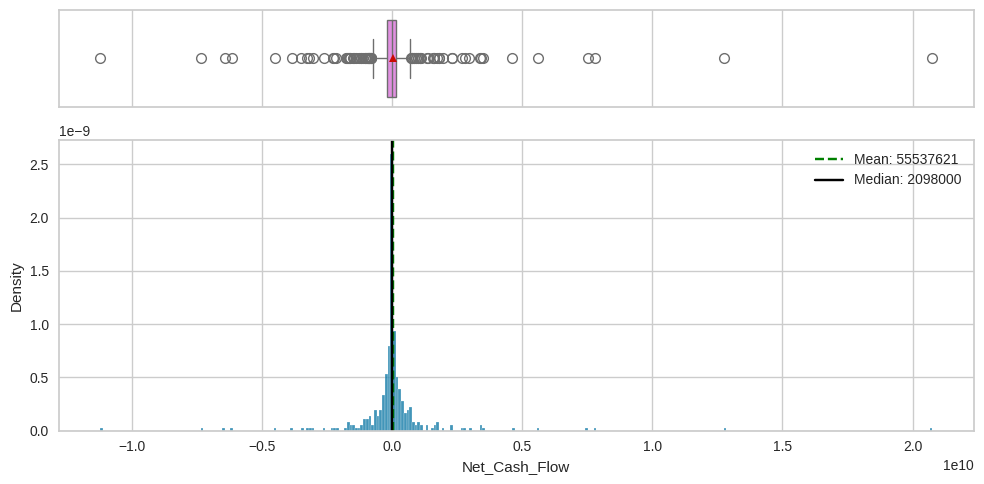

In [ ]:
print("Observations on Net Cash Flow")
print("--"*50)

histogram_boxplot(df, 'Net_Cash_Flow')

The mean and median net cash flow is ~5.5 and ~2.1 miliion respectively with an almost normal distribution.

**Question 1**: What does the distribution of stock prices look like?

Observations on stock prices
----------------------------------------------------------------------------------------------------


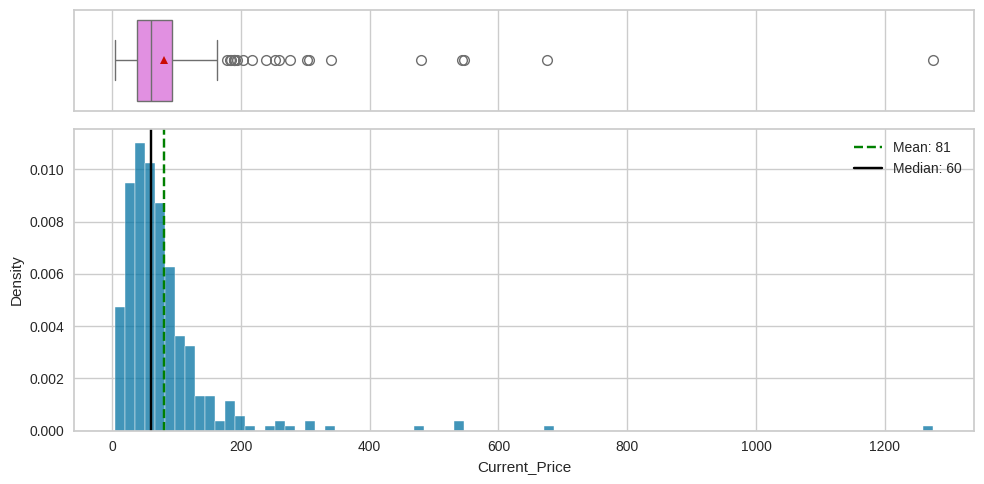

In [ ]:
print("Observations on stock prices")
print("--"*50)

histogram_boxplot(df, 'Current_Price')

- The distribution of the current stock prices is right skewed with some outliers.
- The mean and median stock price is 81 and 60 respectively.

**Question 2**: Which economic sector's stock have seen the maximum price increase on average?

Observations on price change by Economic Sector
----------------------------------------------------------------------------------------------------
                    GICS_Sector  Price_Change
0                   Health Care      9.585652
1              Consumer Staples      8.684750
2        Information Technology      7.217476
3   Telecommunications Services      6.956980
4                   Real Estate      6.205548
5        Consumer Discretionary      5.846093
6                     Materials      5.589738
7                    Financials      3.865406
8                   Industrials      2.833127
9                     Utilities      0.803657
10                       Energy    -10.228289
----------------------------------------------------------------------------------------------------


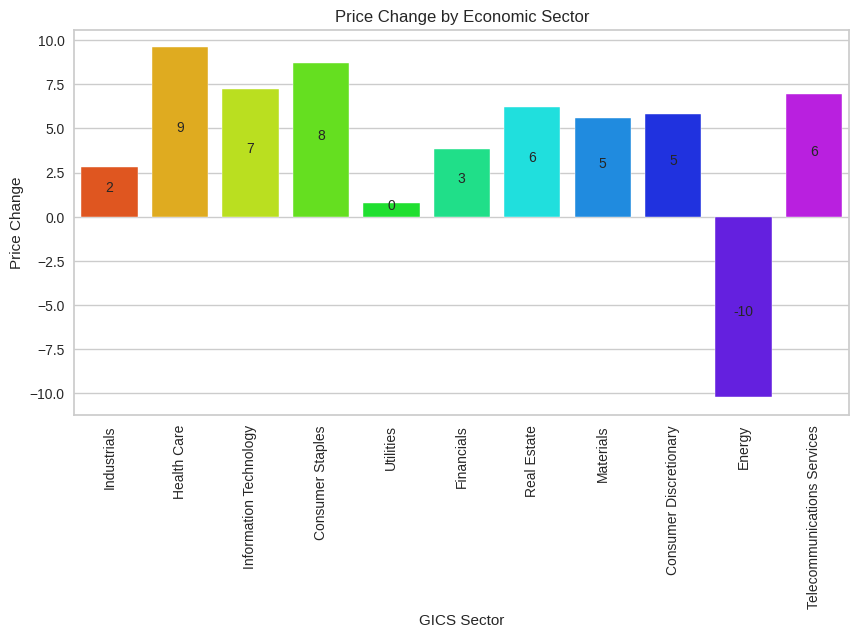


The GICS sector with the highest average price change is 'Health Care' with an average change of 9.59.
----------------------------------------------------------------------------------------------------


In [ ]:
# which economic sector's stock have seen the maximum price increase on average?
print("Observations on price change by Economic Sector")
print("--"*50)

# create groupby table
barplot_data = (df.groupby('GICS_Sector').agg({'Price_Change': 'mean'}).sort_values(by='Price_Change', ascending=False).reset_index())
print(barplot_data)

print("--" * 50)

# show a bar plot
plt.figure(figsize=(10, 5))
plt.title("Price Change by Economic Sector")
plt.xlabel("GICS Sector")
plt.ylabel("Price Change")

ax = sns.barplot(x="GICS_Sector", y="Price_Change", data=df, palette="gist_rainbow", errorbar=None)
plt.xticks(rotation=90)

# Add labels on the bars
for container in ax.containers:
    ax.bar_label(container, fmt="%d", label_type="center", fontsize=10, padding=3)

plt.show();

# Extract the top-performing sector
top_sector = barplot_data.iloc[0]  # First row after sorting

# Print the result
print(f"\nThe GICS sector with the highest average price change is '{top_sector['GICS_Sector']}' with an average change of {top_sector['Price_Change']:.2f}.")
print("--" * 50)

The Health Care sector has the highest Price Change

**Question 3**: How are the different variables correlated with each other?

Observations on Correlation
----------------------------------------------------------------------------------------------------


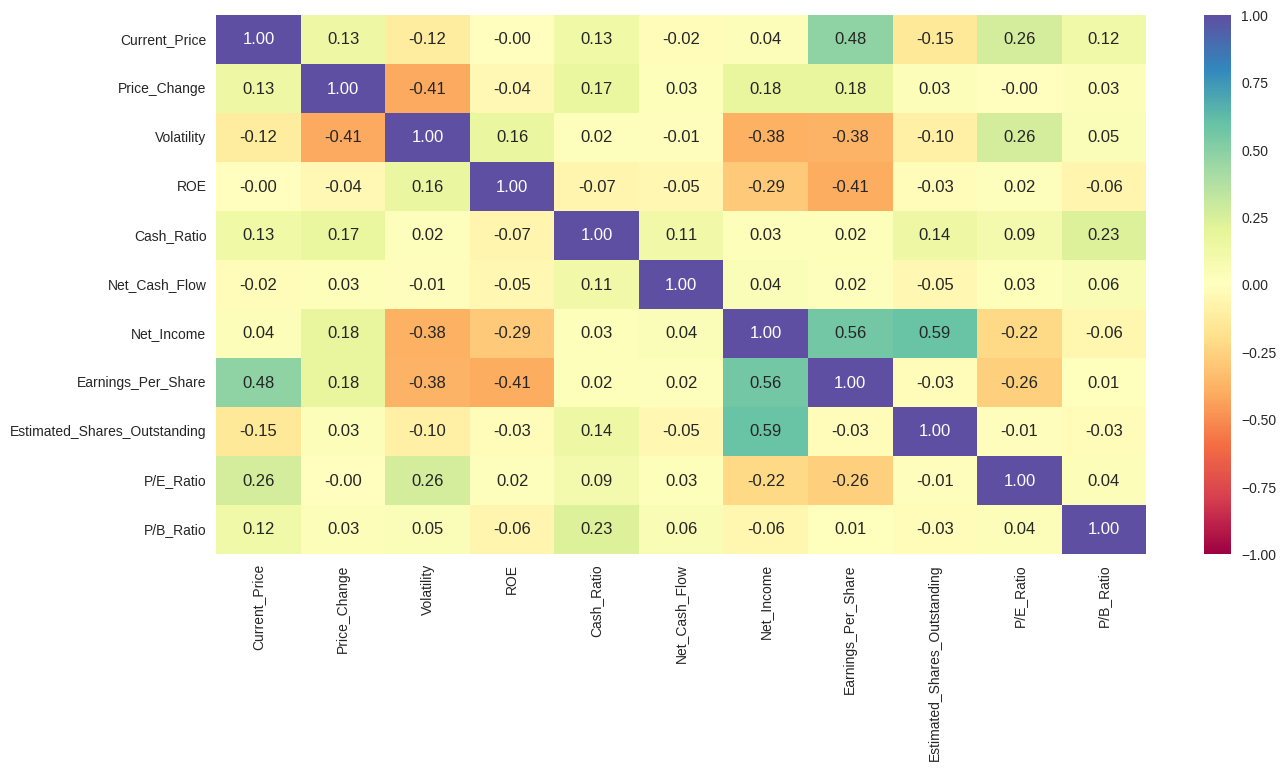

In [ ]:
# How are the different variables correlated with each other?
print("Observations on Correlation")
print("--"*50)
num_cols = df.select_dtypes(include=np.number).columns
plt.figure(figsize=(15, 7))
sns.heatmap(
    df[num_cols].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral"
)
plt.show();

- `Net_Income` correlates positively with `Earnings per Share` and `Estimated Shares Outstanding`, and negatively with `ROE`, `Volatility` and `P/E Ratio`.
- `Volatility` correlate negatively with `Price Change`, `Earnings per Share` and positively with `P/E Ratio`.
- `Current Price` correlate positively with `Earnings per Share` and `P/E Ratio`.


**Question 4:** Cash ratio provides a measure of a company's ability to cover its short-term obligations using only cash and cash equivalents. How does the average cash ratio vary across economic sectors?

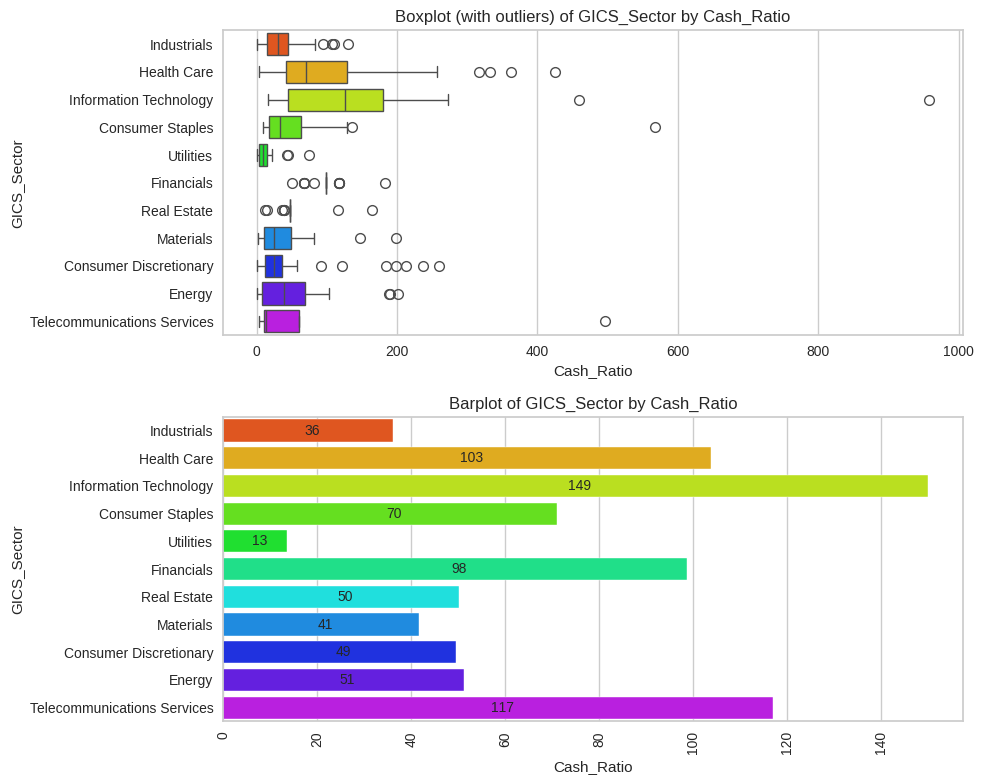

In [ ]:
bivarite_distribution_plot(df, "GICS_Sector", "Cash_Ratio")

- The Information Technology Sector has the highest Cash Ratio, followed by Telecommunications Services, Health Care, and Financials.
- Utilities has the lowest Cash Ratio.

**Question 5**: P/E ratios can help determine the relative value of a company's shares as they signify the amount of money an investor is willing to invest in a single share of a company per dollar of its earnings. How does the P/E ratio vary, on average, across economic sectors?

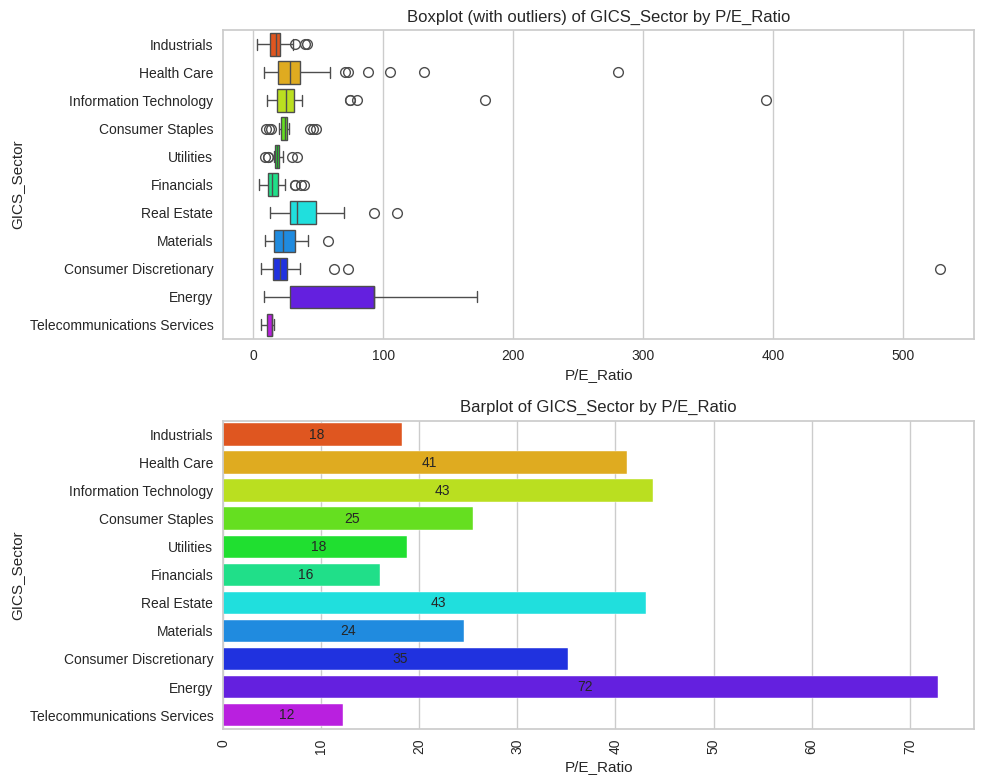

In [ ]:
# How does the P/E ratio vary, on average, across economic sectors?
bivarite_distribution_plot(df, "GICS_Sector", "P/E_Ratio")

P/E ratios can help determine the relative value of a company's shares as they signify the amount of money an investor is willing to invest in a single share of a company per dollar of its earnings.
- The Energy Sector has by far, the highest P/E Ratio, followed by Information Technology, Real Estate, and Health Care.
- Telecommunications Services closely followed by Financials has the lowest Cash Ratio.

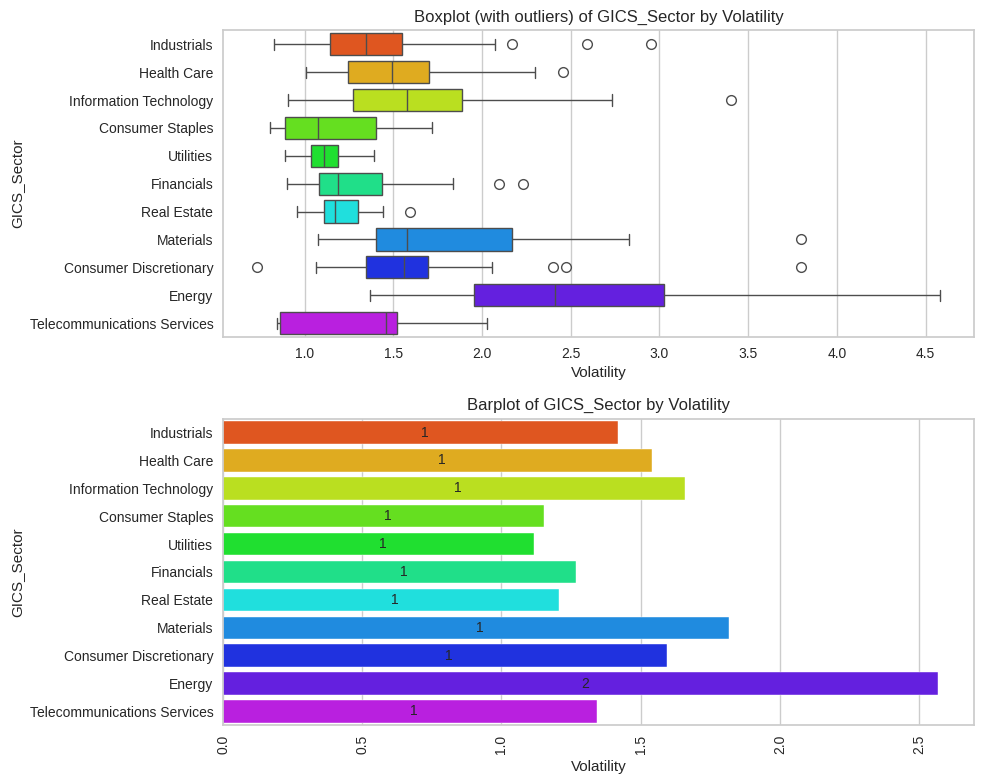

In [ ]:
# How volatility varies, on average, across economic sectors.
bivarite_distribution_plot(df, "GICS_Sector", "Volatility")

Volatility accounts for the fluctuation in the stock price. A stock with high volatility will witness sharper price changes, making it a riskier investment.
  - The Energy sector has the highest Volatility making it one of the sectors with highest risk which can be due to frequent occurence of factors affecting its production and consequently price change and net income.

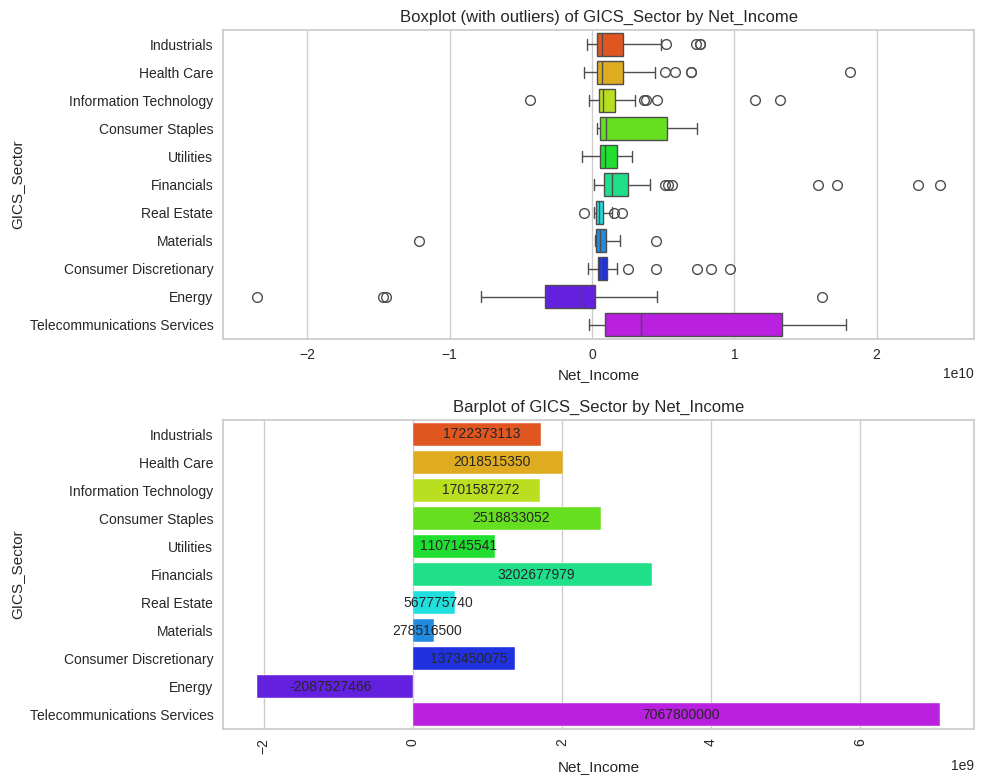

In [ ]:
# How does the Net Income vary, on average, across economic sectors?
bivarite_distribution_plot(df, "GICS_Sector", "Net_Income")

The Energy sector is the only one with a negative Net Income while Telecommunications Services has the highest Net Income.

## Data Preprocessing

### Checking for Outliers on Numerical columns

- We observed some outliers while checking how the GICS performed with some of the variables.
- Now we check for all numerical columns

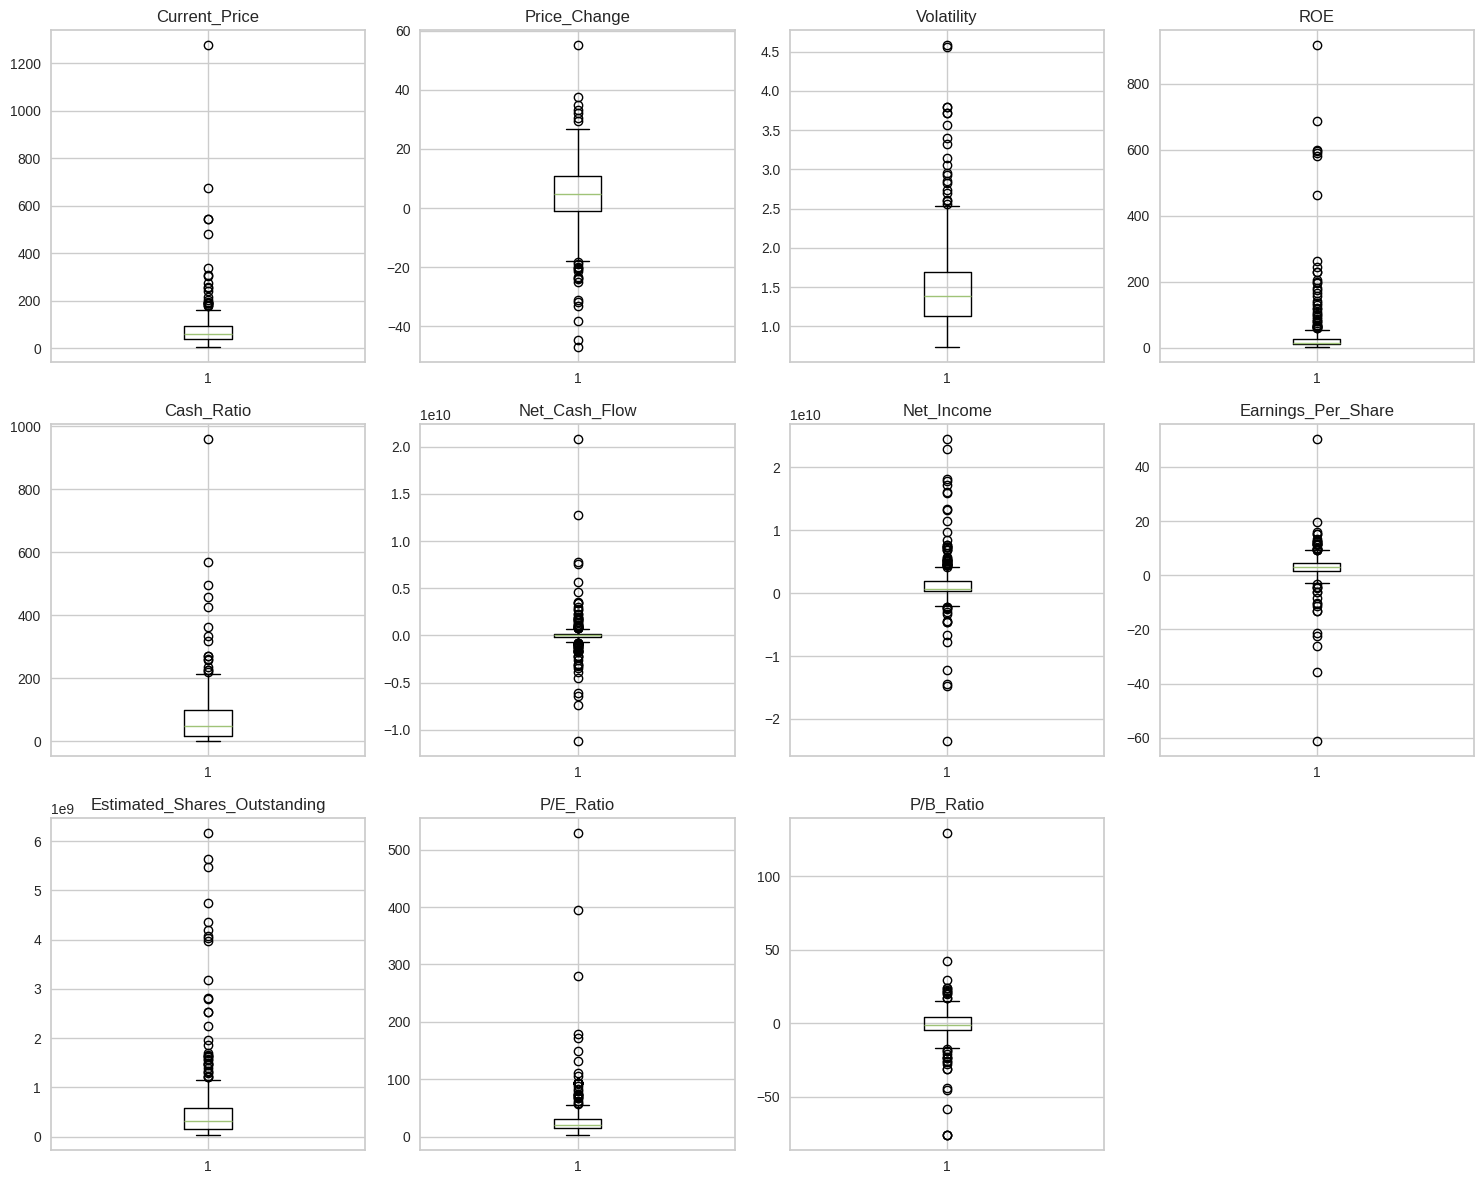

In [ ]:
# check for outliers observed
plt.figure(figsize=(15, 12))


for i, variable in enumerate(num_cols):
    plt.subplot(3, 4, i + 1)
    plt.boxplot(df[variable], whis=1.5)
    plt.tight_layout()
    plt.title(variable)

plt.show()

There are ouliers in all the numerical columns and they are all real data, hence we keep them untreated.

In [ ]:
# treating the outliers by clipping

def preprocess_with_clipping(df, lower=0.01, upper=0.99):
    df_numeric = df.select_dtypes(include=np.number).copy()

    # Winsorize (clip) each numeric column
    for col in df_numeric.columns:
        q_low = df_numeric[col].quantile(lower)
        q_high = df_numeric[col].quantile(upper)
        df_numeric[col] = np.clip(df_numeric[col], q_low, q_high)

    # Scale the clipped data
    scaler = StandardScaler()
    scaled_array = scaler.fit_transform(df_numeric)
    scaled_df = pd.DataFrame(scaled_array, columns=df_numeric.columns)

    return scaled_df


In [ ]:
processed_df = preprocess_with_clipping(df)


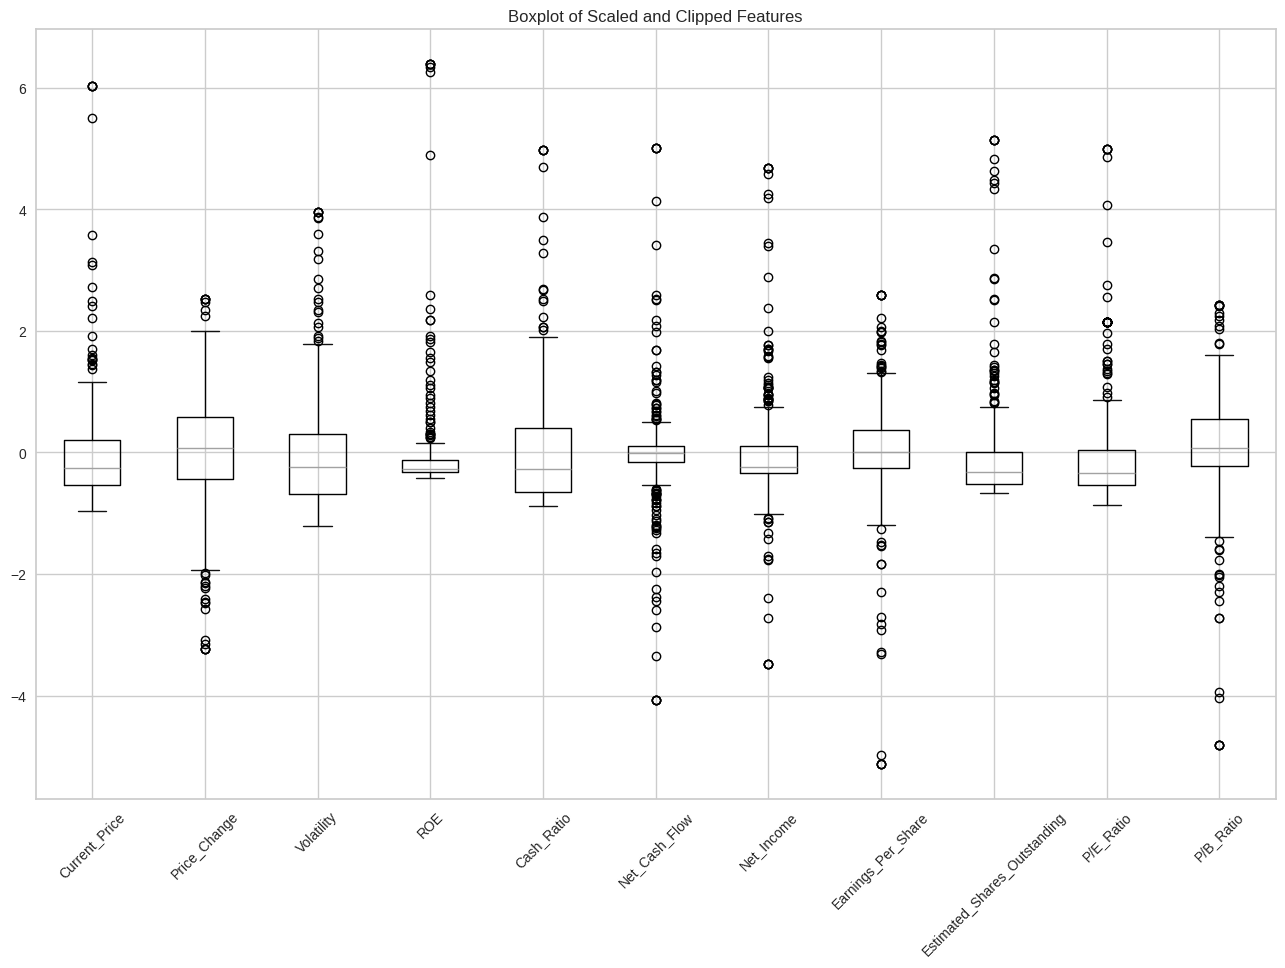

In [ ]:
plt.figure(figsize=(16, 10))
processed_df.boxplot(rot=90)
plt.title("Boxplot of Scaled and Clipped Features")
plt.xticks(rotation=45)
plt.show()

In [ ]:
processed_df.head()

,Current_Price,Price_Change,Volatility,ROE,Cash_Ratio,Net_Cash_Flow,Net_Income,Earnings_Per_Share,Estimated_Shares_Outstanding,P/E_Ratio,P/B_Ratio
0,-0.488922,0.520415,0.291560,1.111332,-0.223265,-0.460942,1.770100,1.774006,0.129854,-0.860697,-0.645501
1,-0.257520,0.374217,1.190631,1.053841,0.118701,0.024025,1.052842,0.066476,1.361269,-0.406345,-0.642307
2,-0.453848,0.634968,-0.436351,-0.199463,-0.012825,0.680766,0.843132,0.022959,1.197154,-0.527625,0.139204
3,0.217890,0.870573,-0.288424,-0.337441,1.473414,-0.192056,-0.260226,-0.325178,-0.085173,1.508580,0.568856
4,-0.311226,-0.520924,0.316236,-0.279950,2.683449,0.219581,-0.240644,-0.522041,2.146121,4.990375,0.275192


## Scaling the Data

In [ ]:
# scaling the data before clustering
scaler = StandardScaler()
subset = df[num_cols].copy()
subset_scaled = scaler.fit_transform(subset)

In [ ]:
# creating a dataframe of the scaled data
subset_scaled_df = pd.DataFrame(subset_scaled, columns=subset.columns)

In [ ]:
# top five rows of the new subset_scaled_df
subset_scaled_df.head()

,Current_Price,Price_Change,Volatility,ROE,Cash_Ratio,Net_Cash_Flow,Net_Income,Earnings_Per_Share,Estimated_Shares_Outstanding,P/E_Ratio,P/B_Ratio
0,-0.393341,0.493950,0.272749,0.989601,-0.210698,-0.339355,1.554415,1.309399,0.107863,-0.652487,-0.506653
1,-0.220837,0.355439,1.137045,0.937737,0.077269,-0.002335,0.927628,0.056755,1.250274,-0.311769,-0.504205
2,-0.367195,0.602479,-0.427007,-0.192905,-0.033488,0.454058,0.744371,0.024831,1.098021,-0.391502,0.094941
3,0.133567,0.825696,-0.284802,-0.317379,1.218059,-0.152497,-0.219816,-0.230563,-0.091622,0.947148,0.424333
4,-0.260874,-0.492636,0.296470,-0.265515,2.237018,0.133564,-0.202703,-0.374982,1.978399,3.293307,0.199196


In [ ]:
# copy of the scaled data
subset_scaled_df2 = subset_scaled_df.copy()

## K-means Clustering

In [ ]:

# create a copy of the scaled df for K-Means clustering
k_means_df = subset_scaled_df.copy()

In [ ]:
# create a copy of the scaled df for K-Means clustering
k_means_df2 = processed_df.copy()

Number of Clusters: 1 	Average Distortion: 2.5425069919221697
Number of Clusters: 2 	Average Distortion: 2.473440999078305
Number of Clusters: 3 	Average Distortion: 2.2741332129391583
Number of Clusters: 4 	Average Distortion: 2.1822426161442072
Number of Clusters: 5 	Average Distortion: 2.121464488815827
Number of Clusters: 6 	Average Distortion: 2.0904498400538674
Number of Clusters: 7 	Average Distortion: 2.025952147311146
Number of Clusters: 8 	Average Distortion: 1.937395817060131
Number of Clusters: 9 	Average Distortion: 1.9267342571601018
Number of Clusters: 10 	Average Distortion: 1.8939910769278663
Number of Clusters: 11 	Average Distortion: 1.81906023992331
Number of Clusters: 12 	Average Distortion: 1.769911516031148
Number of Clusters: 13 	Average Distortion: 1.7170188909300477
Number of Clusters: 14 	Average Distortion: 1.7031921774473986


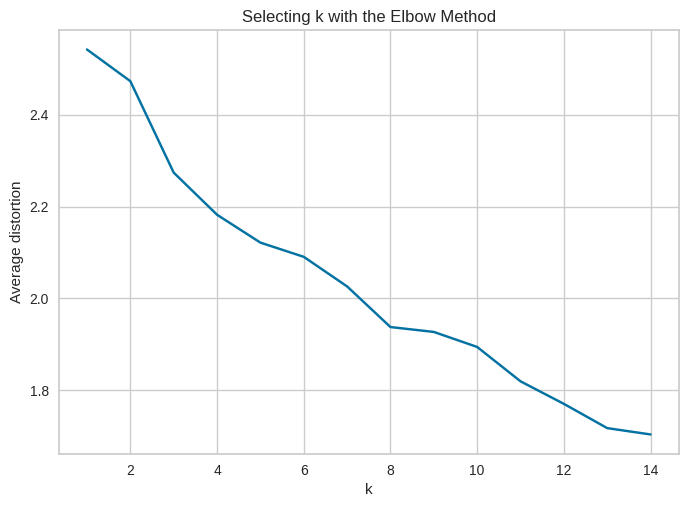

CPU times: user 293 ms, sys: 16.8 ms, total: 310 ms
Wall time: 343 ms


In [ ]:
%%time
# Finding optimal no. of clusters
clusters=range(1,15)

# initialize an empty list
meanDistortions=[]

for k in clusters:
    model = KMeans(n_clusters=k) # creates a K-Means model with the current value of k as the number of clusters.
    model.fit(subset_scaled_df) # fits the model to the data.
    prediction = model.predict(subset_scaled_df) # uses the trained K-Means model to predict the cluster assignments

    # getting the average distortion for the current value of k and appends it to the created list.

    distortion = (
        sum(
            np.min(cdist(subset_scaled_df, model.cluster_centers_, "euclidean"), axis=1)
        )
        / subset_scaled_df.shape[0]
    )

    meanDistortions.append(distortion)

    print("Number of Clusters:", k, "\tAverage Distortion:", distortion)

plt.plot(clusters, meanDistortions, "bx-")
plt.xlabel("k")
plt.ylabel("Average distortion")
plt.title("Selecting k with the Elbow Method")
plt.show()

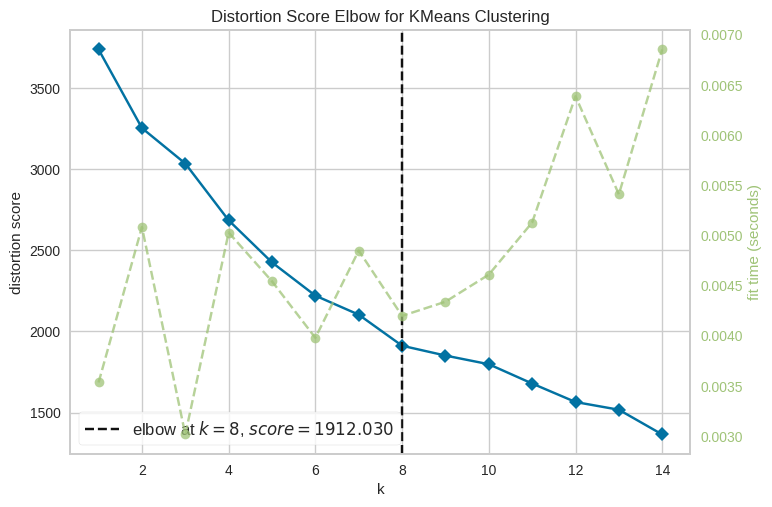

In [ ]:
# Let's determine the optimal number of clusters for K-Means clustering
model = KMeans(random_state=1) #random_state=1 ensures initial placement of centroids is the same every time you run the code for reproducibility.

# creating an instance of the KElbowVisualizer. timings=True is set to record the time taken for each k value during the visualization process.
visualizer = KElbowVisualizer(model, k=(1, 15), timings=True)

# fit the data to the visualizer
visualizer.fit(k_means_df)

visualizer.show();  # finalize and render figure

From the elbow chart and distortion values:

- There's a noticeable “elbow” or inflection point around k = 5 or 6, where the rate of decrease in distortion slows down.

- The decrease in distortion from k=6 (2.0608) to k=7 (2.0493) is very small (0.0115).
- While the distortion continues to decrease after k=7 (with an anomaly at k=10 where it slightly increases), the rate of decrease from k=6 to k=7 is the first point after k=5 where the improvement becomes marginal.

- This puts our optimal clusters within or between 5 and 7.

### Let's check the silhouette scores to also determine the optimal number of clusters for K-Means



For n_clusters = 2, the silhouette score is 0.45335782729503565)
For n_clusters = 3, the silhouette score is 0.40374060030338865)
For n_clusters = 4, the silhouette score is 0.4246430808437099)
For n_clusters = 5, the silhouette score is 0.4381539778147092)
For n_clusters = 6, the silhouette score is 0.40869599703024256)
For n_clusters = 7, the silhouette score is 0.1207450219233897)
For n_clusters = 8, the silhouette score is 0.3693991650696542)
For n_clusters = 9, the silhouette score is 0.35185096182499204)
For n_clusters = 10, the silhouette score is 0.32950073703610283)
For n_clusters = 11, the silhouette score is 0.1486586842527321)
For n_clusters = 12, the silhouette score is 0.15784241071085106)
For n_clusters = 13, the silhouette score is 0.15646997458716602)
For n_clusters = 14, the silhouette score is 0.16253506827999134)


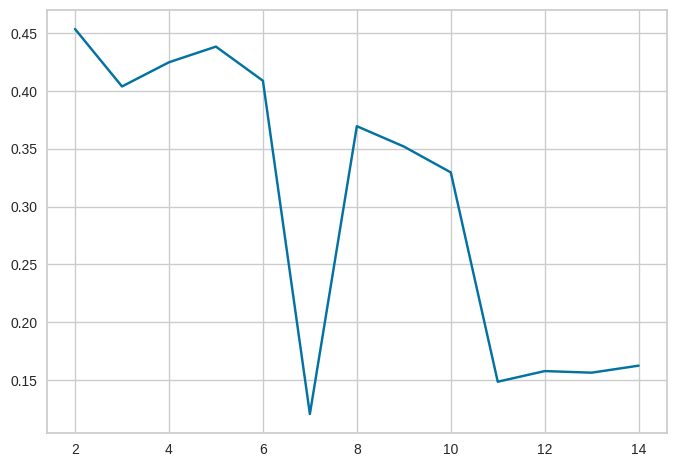

CPU times: user 644 ms, sys: 6.82 ms, total: 651 ms
Wall time: 378 ms


In [ ]:
%%time
#  calculate and visualize the silhouette scores to determine the optimal number of clusters for K-Means
sil_score = []  # initiate variable to store
cluster_list = range(2, 15)
for n_clusters in cluster_list:
    clusterer = KMeans(n_clusters=n_clusters, random_state=1)
    preds = clusterer.fit_predict((subset_scaled_df))
    score = silhouette_score(k_means_df, preds)
    sil_score.append(score)
    print("For n_clusters = {}, the silhouette score is {})".format(n_clusters, score))

plt.plot(cluster_list, sil_score)
plt.show()

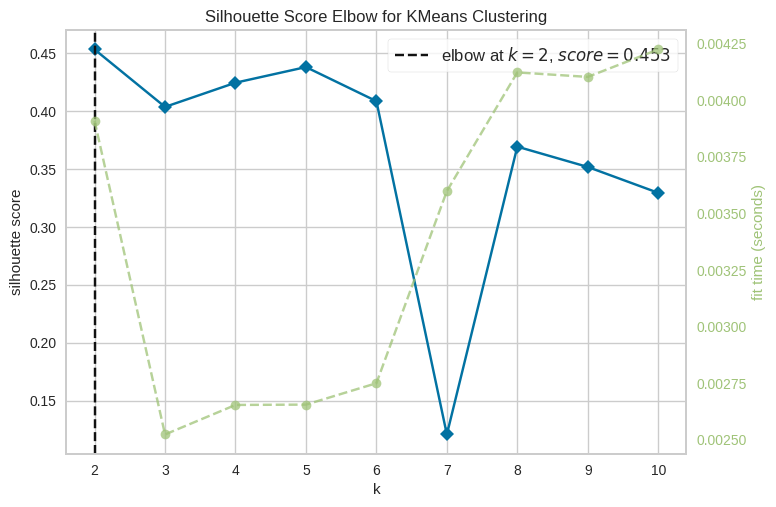

CPU times: user 435 ms, sys: 6.24 ms, total: 441 ms
Wall time: 273 ms


<Axes: title={'center': 'Silhouette Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='silhouette score'>

In [ ]:
%%time
# visualize the timing of the silhouette scores
model = KMeans(random_state=1)
visualizer = KElbowVisualizer(model, k=(2, 11), metric="silhouette", timings=True)
visualizer.fit(k_means_df)  # fit the data to the visualizer
visualizer.show();  # finalize and render figure

From the changes in the coefficients and from the previous analysis (using the Elbow Method and Silhouette Score plots for various k values), it points that the optimal number of clusters might be around k values of 5, 6, or 7.
- We will plot the silhouette visualizer using 5,6 and 7 clusters respectively.
- Then we compare which number of clusters results in more distinct and well-separated groupings of data points.

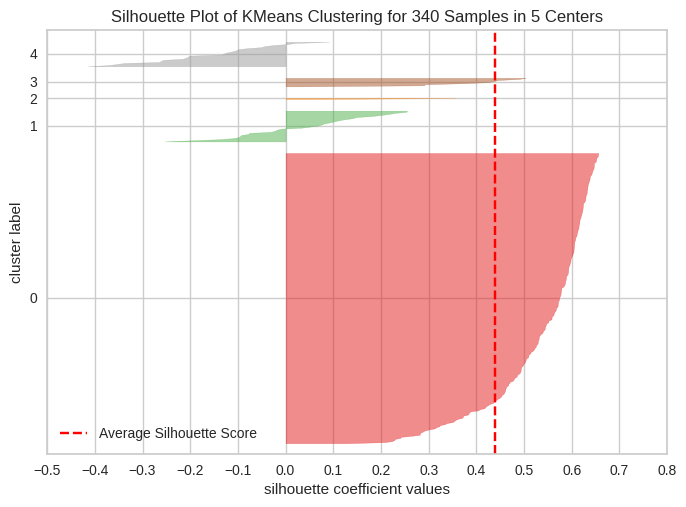

CPU times: user 265 ms, sys: 6.86 ms, total: 272 ms
Wall time: 158 ms


<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 340 Samples in 5 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [ ]:
%%time
# finding optimal no. of clusters with silhouette coefficients at k = 5
visualizer = SilhouetteVisualizer(KMeans(5, random_state=1))
visualizer.fit(k_means_df)
visualizer.show();

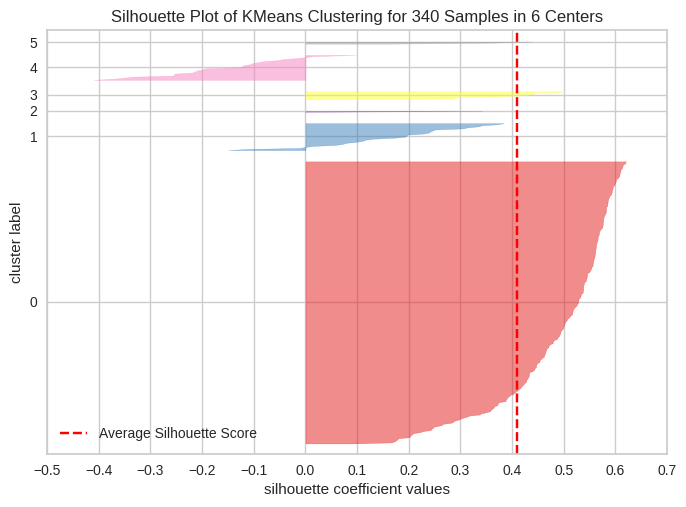

CPU times: user 279 ms, sys: 2.16 ms, total: 281 ms
Wall time: 161 ms


<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 340 Samples in 6 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [ ]:
%%time
# finding optimal no. of clusters with silhouette coefficients at k = 6
visualizer = SilhouetteVisualizer(KMeans(6, random_state=1))
visualizer.fit(k_means_df)
visualizer.show();

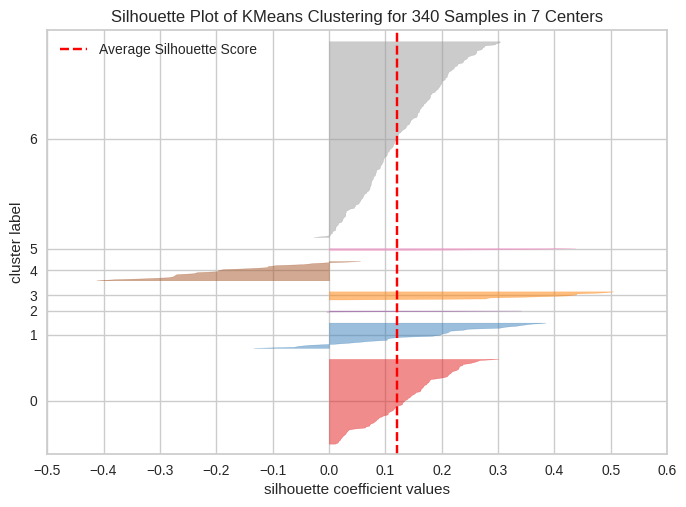

CPU times: user 482 ms, sys: 3.34 ms, total: 485 ms
Wall time: 364 ms


<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 340 Samples in 7 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [ ]:
%%time
# finding optimal no. of clusters with silhouette coefficients at k = 7
visualizer = SilhouetteVisualizer(KMeans(7, random_state=1))
visualizer.fit(k_means_df)
visualizer.show();

- For k=5: The average silhouette score appears to be the highest among the three options, around 0.44.
    - The clusters have a substantial number of samples (indicated by their thickness).
    - A good proportion of samples in the cluster have silhouette scores above the average with both clusters appear relatively well-formed.


- For k=6: The average silhouette score is around 0.41, which is lower than for
k=5.
    - All clusters are quite thick. We see some part of the clusters deeping more below (< -0.1) the negative mark making it less suitable to be used.

- For k=7: The average silhouette score is around 0.12, which is lower than for
k=5 and k=6.
    - All clusters are quite thick. We see some part of the clusters deeping more below (< -0.1) the negative mark making it less suitable to be used.

We will adopt the **k=5** clusters because it yields the highest average silhouette score ~0.44 and clear variable-driven differentiation.

### Selecting final model

In [ ]:
%%time
# final K-means model
kmeans = KMeans(n_clusters=5, random_state=0)
kmeans.fit(subset_scaled_df)

CPU times: user 7.51 ms, sys: 763 µs, total: 8.27 ms
Wall time: 9.63 ms


KMeans(n_clusters=5, random_state=0)

In [ ]:
%%time
# creating a copy of the original data
df1 = df.copy()

# adding kmeans cluster labels to the original and scaled dataframes
k_means_df["KM_segments"] = kmeans.labels_
df1["KM_segments"] = kmeans.labels_

CPU times: user 1.75 ms, sys: 0 ns, total: 1.75 ms
Wall time: 1.78 ms


### Cluster Profiling

In [ ]:
%%time
# create a cluster profile with the numeric columns
km_cluster_profile = df1.groupby("KM_segments")[num_cols].mean()


CPU times: user 5.28 ms, sys: 39 µs, total: 5.32 ms
Wall time: 10.9 ms


In [ ]:
%%time
# Count based on Security Column
km_cluster_profile["count_in_each_segment"] = (
    df1.groupby("KM_segments")["Security"].count().values
)

CPU times: user 3 ms, sys: 0 ns, total: 3 ms
Wall time: 3.7 ms


In [ ]:
%%time
# Displaying the cluster profiles
km_cluster_profile.style.highlight_max(color="lightgreen", axis=0)

CPU times: user 131 ms, sys: 1.61 ms, total: 132 ms
Wall time: 143 ms


,Current_Price,Price_Change,Volatility,ROE,Cash_Ratio,Net_Cash_Flow,Net_Income,Earnings_Per_Share,Estimated_Shares_Outstanding,P/E_Ratio,P/B_Ratio,count_in_each_segment
KM_segments,,,,,,,,,,,,
0,73.440560,5.005125,1.386248,34.934545,52.240000,-18047505.454545,1486648294.545455,3.691400,428661209.833855,23.544684,-3.407835,275
1,35.165385,-16.390175,2.922214,110.961538,49.461538,-192318884.615385,-4041692307.692307,-9.849231,482610056.416923,78.934814,1.612922,26
2,179.298133,14.177395,1.809455,23.360000,278.720000,818621280.000000,732044960.000000,3.338400,590618012.638000,93.058018,14.694419,25
3,48.103077,6.053507,1.163964,27.538462,77.230769,773230769.230769,14114923076.923077,3.958462,3918734987.169230,16.098039,-4.253404,13
4,1274.949951,3.190527,1.268340,29.000000,184.000000,-1671386000.000000,2551360000.000000,50.090000,50935516.070000,25.453183,-1.052429,1


In [ ]:
%%time
# print the companies in each cluster
for cl in df1["KM_segments"].unique():
    print("In cluster {}, the following companies are present:".format(cl))
    print(df1[df1["KM_segments"] == cl]["Security"].unique())
    print()

In cluster 0, the following companies are present:
['American Airlines Group' 'AbbVie' 'Abbott Laboratories'
 'Archer-Daniels-Midland Co' 'Ameren Corp' 'American Electric Power'
 'AFLAC Inc' 'American International Group, Inc.'
 'Apartment Investment & Mgmt' 'Assurant Inc' 'Arthur J. Gallagher & Co.'
 'Akamai Technologies Inc' 'Albemarle Corp' 'Alaska Air Group Inc'
 'Allstate Corp' 'Allegion' 'Applied Materials Inc' 'AMETEK Inc'
 'Affiliated Managers Group Inc' 'Ameriprise Financial'
 'American Tower Corp A' 'AutoNation Inc' 'Anthem Inc.' 'Aon plc'
 'Amphenol Corp' 'Arconic Inc' 'Activision Blizzard'
 'AvalonBay Communities, Inc.' 'Broadcom'
 'American Water Works Company Inc' 'American Express Co' 'Boeing Company'
 'Baxter International Inc.' 'BB&T Corporation' 'Bard (C.R.) Inc.'
 'BIOGEN IDEC Inc.' 'The Bank of New York Mellon Corp.' 'Ball Corp'
 'Bristol-Myers Squibb' 'Boston Scientific' 'BorgWarner'
 'Boston Properties' 'Caterpillar Inc.' 'Chubb Limited' 'CBRE Group'
 'Crown Castl

In [ ]:
%%time
# Check the count by GICS Sectors and clusters
df1.groupby(["KM_segments", "GICS_Sector"])['Security'].count()

CPU times: user 3.26 ms, sys: 0 ns, total: 3.26 ms
Wall time: 3.34 ms


KM_segments  GICS_Sector                
0            Consumer Discretionary         33
             Consumer Staples               17
             Energy                          6
             Financials                     45
             Health Care                    29
             Industrials                    52
             Information Technology         23
             Materials                      18
             Real Estate                    26
             Telecommunications Services     2
             Utilities                      24
1            Energy                         22
             Industrials                     1
             Information Technology          2
             Materials                       1
2            Consumer Discretionary          5
             Consumer Staples                1
             Energy                          1
             Health Care                     8
             Information Technology          7
             Materials                       1
             Real Estate                     1
             Telecommunications Services     1
3            Consumer Discretionary          1
             Consumer Staples                1
             Energy                          1
             Financials                      4
             Health Care                     3
             Information Technology          1
             Telecommunications Services     2
4            Consumer Discretionary          1
Name: Security, dtype: int64

### Visualizing the distribution of the numerical variables within each cluster that was identified by the K-Means

CPU times: user 3.24 s, sys: 52.4 ms, total: 3.29 s
Wall time: 4.79 s


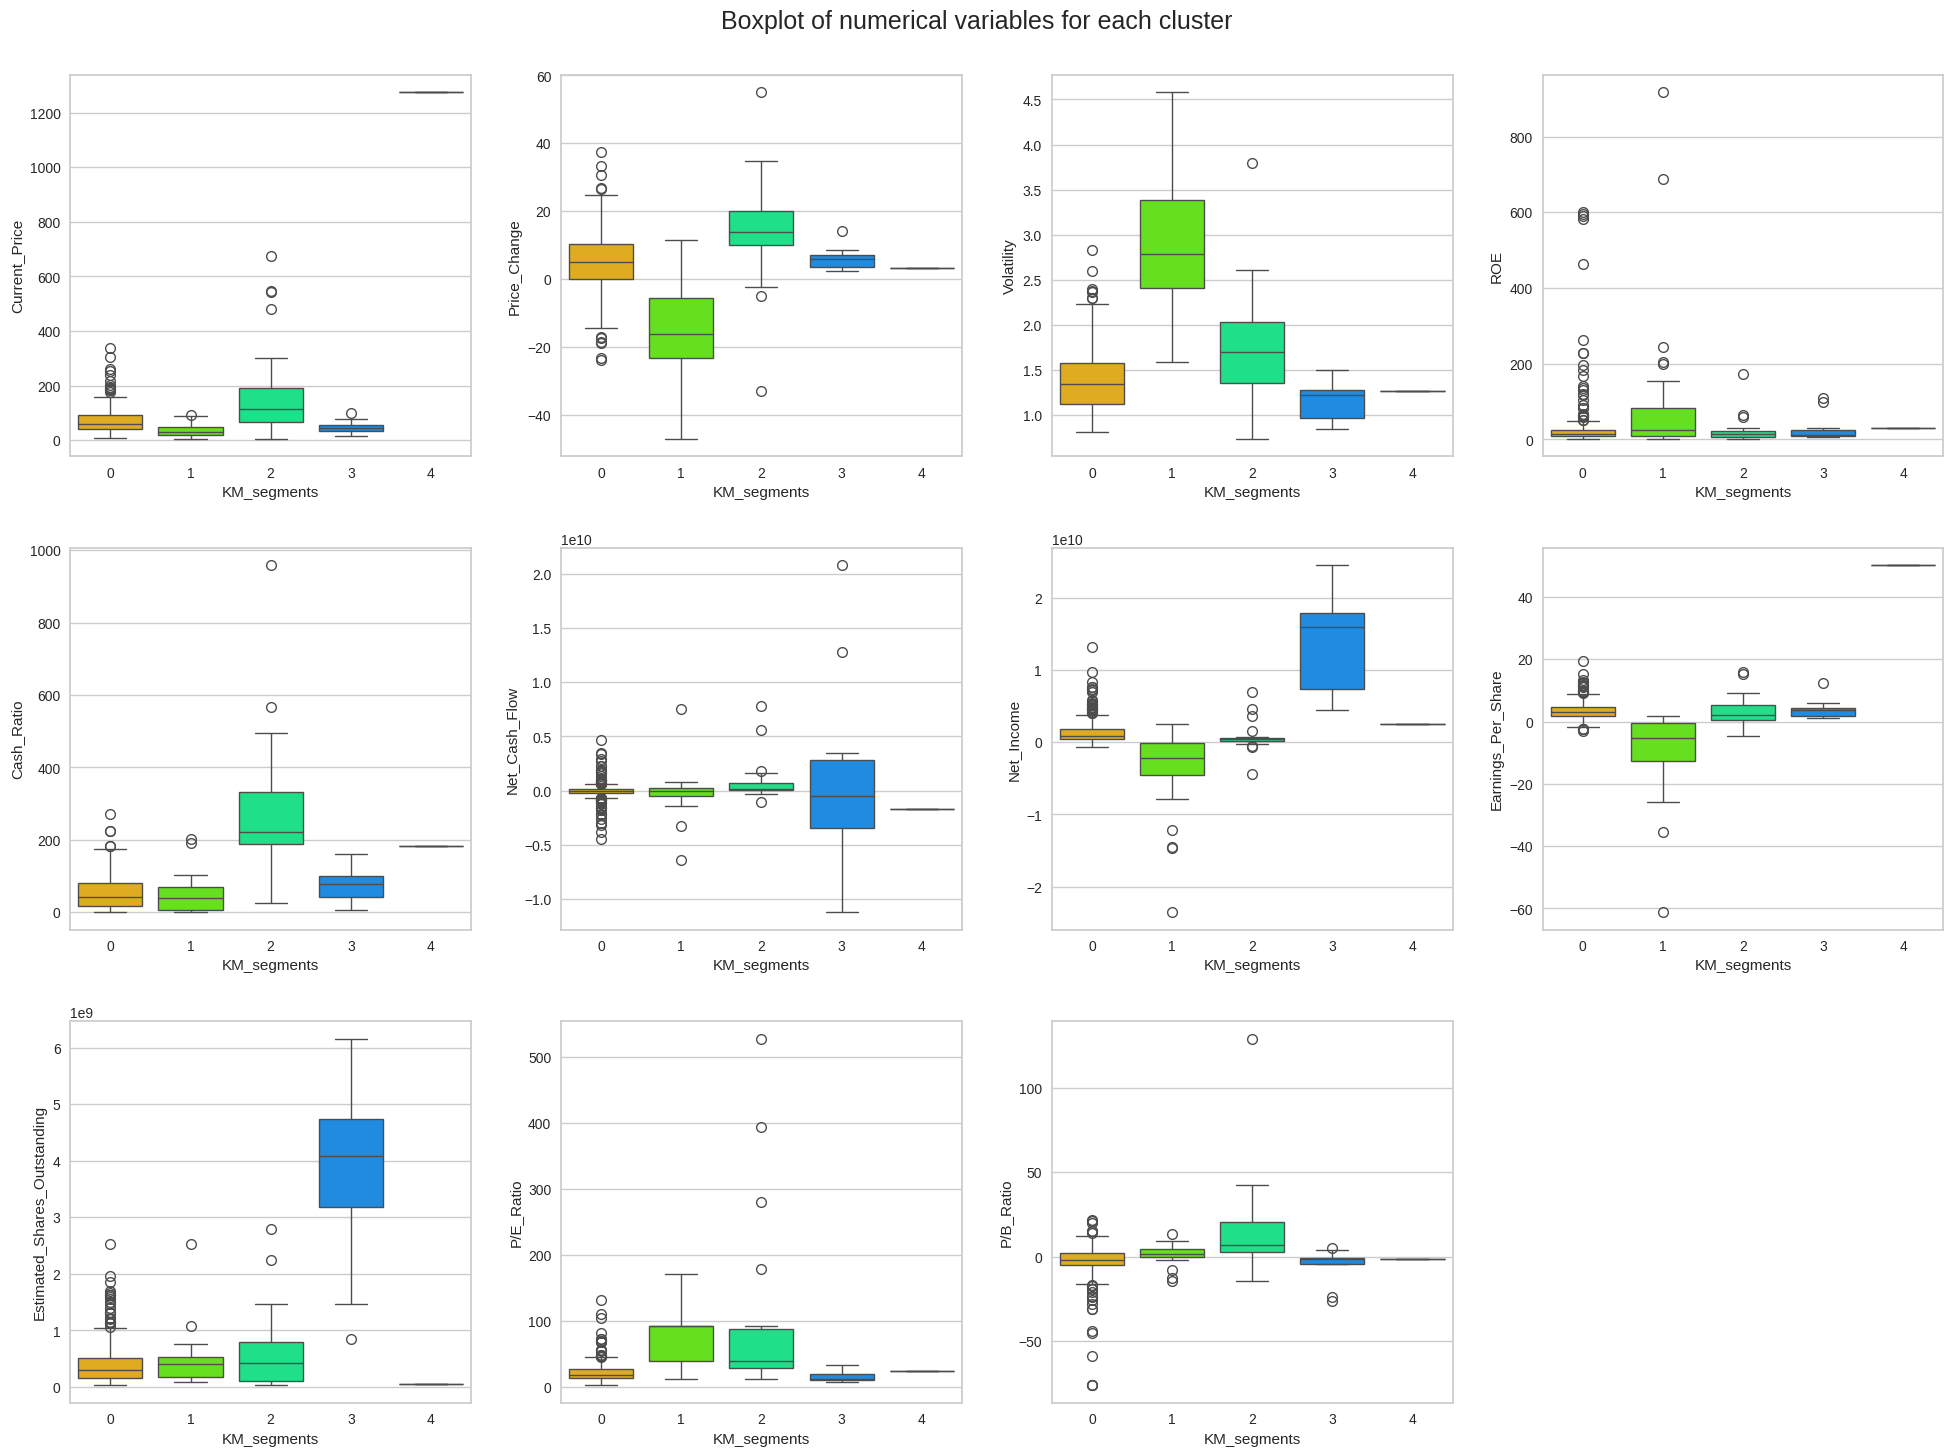

In [ ]:
%%time
# Visualizing the distribution of the numerical variables within each K-Means cluster

plt.figure(figsize=(20, 15))
plt.suptitle("Boxplot of numerical variables for each cluster", fontsize=18)

for i, variable in enumerate(num_cols):
    plt.subplot(3, 4, i + 1)
    sns.boxplot(data=df1, x="KM_segments", y=variable, palette="gist_rainbow")
    plt.tight_layout()


plt.tight_layout(pad=2.0);

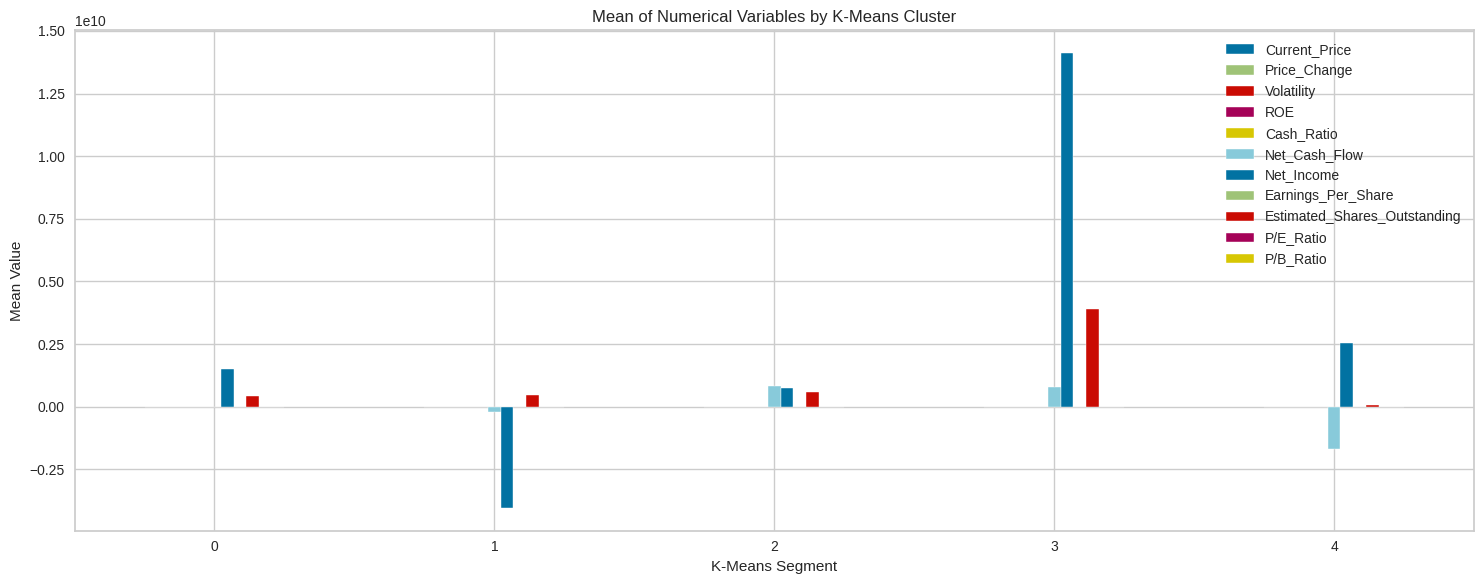

CPU times: user 579 ms, sys: 8.93 ms, total: 588 ms
Wall time: 621 ms


In [ ]:
%%time
# Calculate the mean for numerical columns within each cluster and plot the bar chart
# Use numeric_only=True to only calculate mean for numerical columns
df1.groupby("KM_segments").mean(numeric_only=True).plot.bar(figsize=(15, 6))
plt.title("Mean of Numerical Variables by K-Means Cluster") # Add a title for better clarity
plt.xlabel("K-Means Segment")
plt.ylabel("Mean Value")
plt.xticks(rotation=0) # Rotate x-axis labels back to horizontal
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

###Overall Observations:
The K-Means clustering has successfully identified segments with distinct financial profiles. Each segment exhibits different characteristics in terms of price, growth, profitability, volatility, and financial health.

## Insights from K-Means Cluster

:**Cluster 0**
  - Current Price: Wide range with many outliers, generally mid to high prices.

  - Price Change: Mixed but with a slight positive tendency.

  - Volatility: Low to moderate, indicating more stable stocks.

  - ROE: Moderate, with a few high outliers.

  - Cash Ratio: Moderate.

  - Net Cash Flow: Slightly negative to neutral.

  - Net Income: Mostly positive.

  - EPS: Mostly positive, with some variation.
  
  - Estimated Shares Outstanding: Moderate.

  - P/E Ratio: Mostly below 50, some outliers up to 150+.

  - P/B Ratio: Moderate, with some extreme negatives/outliers.

✅::**Overall**: Mid-priced, moderately stable companies with average ROE and decent financial performance. They don't consistently excel or underperform in one specific area but carry a degree of unpredictability worth monitoring.


**Cluster 1**
- Current Price: Generally low.

- Price Change: Negative tendency; several large negative changes, suggesting declining stock values.

- Volatility: High; most volatile group, indicating significant price swings.

- ROE: Low to moderate with outliers.

- Cash Ratio: Mostly low, suggesting poor liquidity.

- Net Cash Flow: Around zero to negative with some extreme values.

- Net Income: Negative median; struggling profitability.

- EPS: Negative for many, indicating loss-making companies.

- Estimated Shares Outstanding: Low to moderate.

- P/E Ratio: Highly variable, with extreme outliers (over 500) indicating overvaluation or low earnings..

- P/B Ratio: Mostly low to mid, but a few inflated outliers.



❌ **Overall**: This is a high-risk group with poor financial performance, volatile prices, and often negative earnings. It has a risky investment profile with what could be distressed companies.


**Cluster 2**
- Current_Price: Higher median current price compared to most other segments.

- Price_Change: The highest positive median price change, indicating strong stock appreciation.

- Volatility: High median volatility (second highest), often associated with growth stocks.

- ROE (Return on Equity): High positive median ROE.

- Cash_Ratio: The highest median cash ratio, indicating strong liquidity and financial health.

- Net_Cash_Flow: The highest positive median net cash flow.

- Net_Income: Healthy positive median net income.

- Earnings_Per_Share (EPS): Strong positive median EPS.

- P/E & P/B Ratios: Reasonable, with healthy variation.

- Estimated Shares Outstanding: Moderate.

✅ **Overall**: Financially healthy growth companies. Good earners with appreciating stock prices, strong profitability across multiple metrics (ROE, Net Income, EPS), healthy cash generation, and excellent liquidity. Ideal for mid to long-term investors.


**Cluster 3**
- Current_Price: The lowest median current price.

- Price_Change: Median price change is minimal, close to zero.

- Volatility: The lowest median volatility, suggesting price stability.

- ROE (Return on Equity): The lowest median ROE, close to zero or slightly negative.

- Cash_Ratio: Moderate median cash ratio.

- Net Cash Flow: Mostly positive with some negatives.

- Net Income: Very high; some extreme values.

- EPS: Mostly positive, with tight distribution.

- Estimated Shares Outstanding: Highest of all clusters (often in the billions).

- P/E & P/B Ratios: Moderate - Low and consistent.


✅ **Overall**: Likely mature large-cap, stable blue-chip companies with huge market reach, high profitability, large equity bases (significant non-cash expenses/income) diluting ROE, and consistent performance — ideal for conservative investors.



**Cluster 4**

- Current Price: Low and consistent.

- Price Change: Very flat; almost no change.

- Volatility: Very low and uniform, suggesting price stability.

- ROE: Very low, close to zero or slightly negative.

- Cash Ratio: Mid-high and consistent.

- Net Cash Flow, Net Income, EPS: Extremely consistent, very low variability.

- Estimated Shares Outstanding: Near zero.

- P/E and P/B Ratios: Almost constant at near zero across samples.

🟨**Overall**: This cluster is characterized by exceptional stability across most metrics. Minimal variability indicates little market action that is suggestive of mature homogenous companies in stable industries with limited growth prospects but predictable performance.

## Hierarchical Clustering

In [ ]:
# create copy of scaled data
hc_df = subset_scaled_df.copy()

In [ ]:
%%time
# list of distance metrics
distance_metrics = ["euclidean", "chebyshev", "mahalanobis", "cityblock"]

# list of linkage methods
linkage_methods = ["single", "complete", "average", "weighted"]

high_cophenet_corr = 0
high_dm_lm = [0, 0]

for dm in distance_metrics:
    for lm in linkage_methods:
        Z = linkage(hc_df, metric=dm, method=lm)
        c, coph_dists = cophenet(Z, pdist(hc_df))
        print(
            "Cophenetic correlation for {} distance and {} linkage is {}.".format(
                dm.capitalize(), lm, c
            )
        )
        if high_cophenet_corr < c:
            high_cophenet_corr = c
            high_dm_lm[0] = dm
            high_dm_lm[1] = lm

# printing the combination of distance metric and linkage method with the highest cophenetic correlation
print('*'*100)
print(
    "Highest cophenetic correlation is {}, which is obtained with {} distance and {} linkage.".format(
        high_cophenet_corr, high_dm_lm[0].capitalize(), high_dm_lm[1]
    )
)

Cophenetic correlation for Euclidean distance and single linkage is 0.9232271494002922.
Cophenetic correlation for Euclidean distance and complete linkage is 0.7873280186580672.
Cophenetic correlation for Euclidean distance and average linkage is 0.9422540609560814.
Cophenetic correlation for Euclidean distance and weighted linkage is 0.8693784298129404.
Cophenetic correlation for Chebyshev distance and single linkage is 0.9062538164750717.
Cophenetic correlation for Chebyshev distance and complete linkage is 0.598891419111242.
Cophenetic correlation for Chebyshev distance and average linkage is 0.9338265528030499.
Cophenetic correlation for Chebyshev distance and weighted linkage is 0.9127355892367.
Cophenetic correlation for Mahalanobis distance and single linkage is 0.925919553052459.
Cophenetic correlation for Mahalanobis distance and complete linkage is 0.7925307202850002.
Cophenetic correlation for Mahalanobis distance and average linkage is 0.9247324030159736.
Cophenetic correla

Let's get the combination with the highest cophenetic correlation

#### **Let's explore different linkage methods with Euclidean distance only.**

In [ ]:
%%time
# list of linkage methods
linkage_methods = ["single", "complete", "average", "centroid", "ward", "weighted"]

high_cophenet_corr = 0
high_dm_lm = [0, 0]

for lm in linkage_methods:
    Z = linkage(hc_df, metric="euclidean", method=lm)
    c, coph_dists = cophenet(Z, pdist(hc_df))
    print("Cophenetic correlation for {} linkage is {}.".format(lm, c))
    if high_cophenet_corr < c:
        high_cophenet_corr = c
        high_dm_lm[0] = "euclidean"
        high_dm_lm[1] = lm

# printing the combination of distance metric and linkage method with the highest cophenetic correlation
print('*'*100)
print(
    "Highest cophenetic correlation is {}, which is obtained with {} linkage.".format(
        high_cophenet_corr, high_dm_lm[1]
    )
)

Cophenetic correlation for single linkage is 0.9232271494002922.
Cophenetic correlation for complete linkage is 0.7873280186580672.
Cophenetic correlation for average linkage is 0.9422540609560814.
Cophenetic correlation for centroid linkage is 0.9314012446828154.
Cophenetic correlation for ward linkage is 0.7101180299865353.
Cophenetic correlation for weighted linkage is 0.8693784298129404.
****************************************************************************************************
Highest cophenetic correlation is 0.9422540609560814, which is obtained with average linkage.
CPU times: user 35.9 ms, sys: 2.88 ms, total: 38.8 ms
Wall time: 38.7 ms


**Observations**

- We see that the cophenetic correlation is maximum with Euclidean distance and average linkage.
- The cophenetic correlation with Euclidean distance and average linkage is the same with the combination with maximum cophenetic correlation observed earlier.

**Let's view the dendrograms for the different linkage methods with Euclidean distance.**

CPU times: user 2.83 s, sys: 45.8 ms, total: 2.87 s
Wall time: 2.92 s


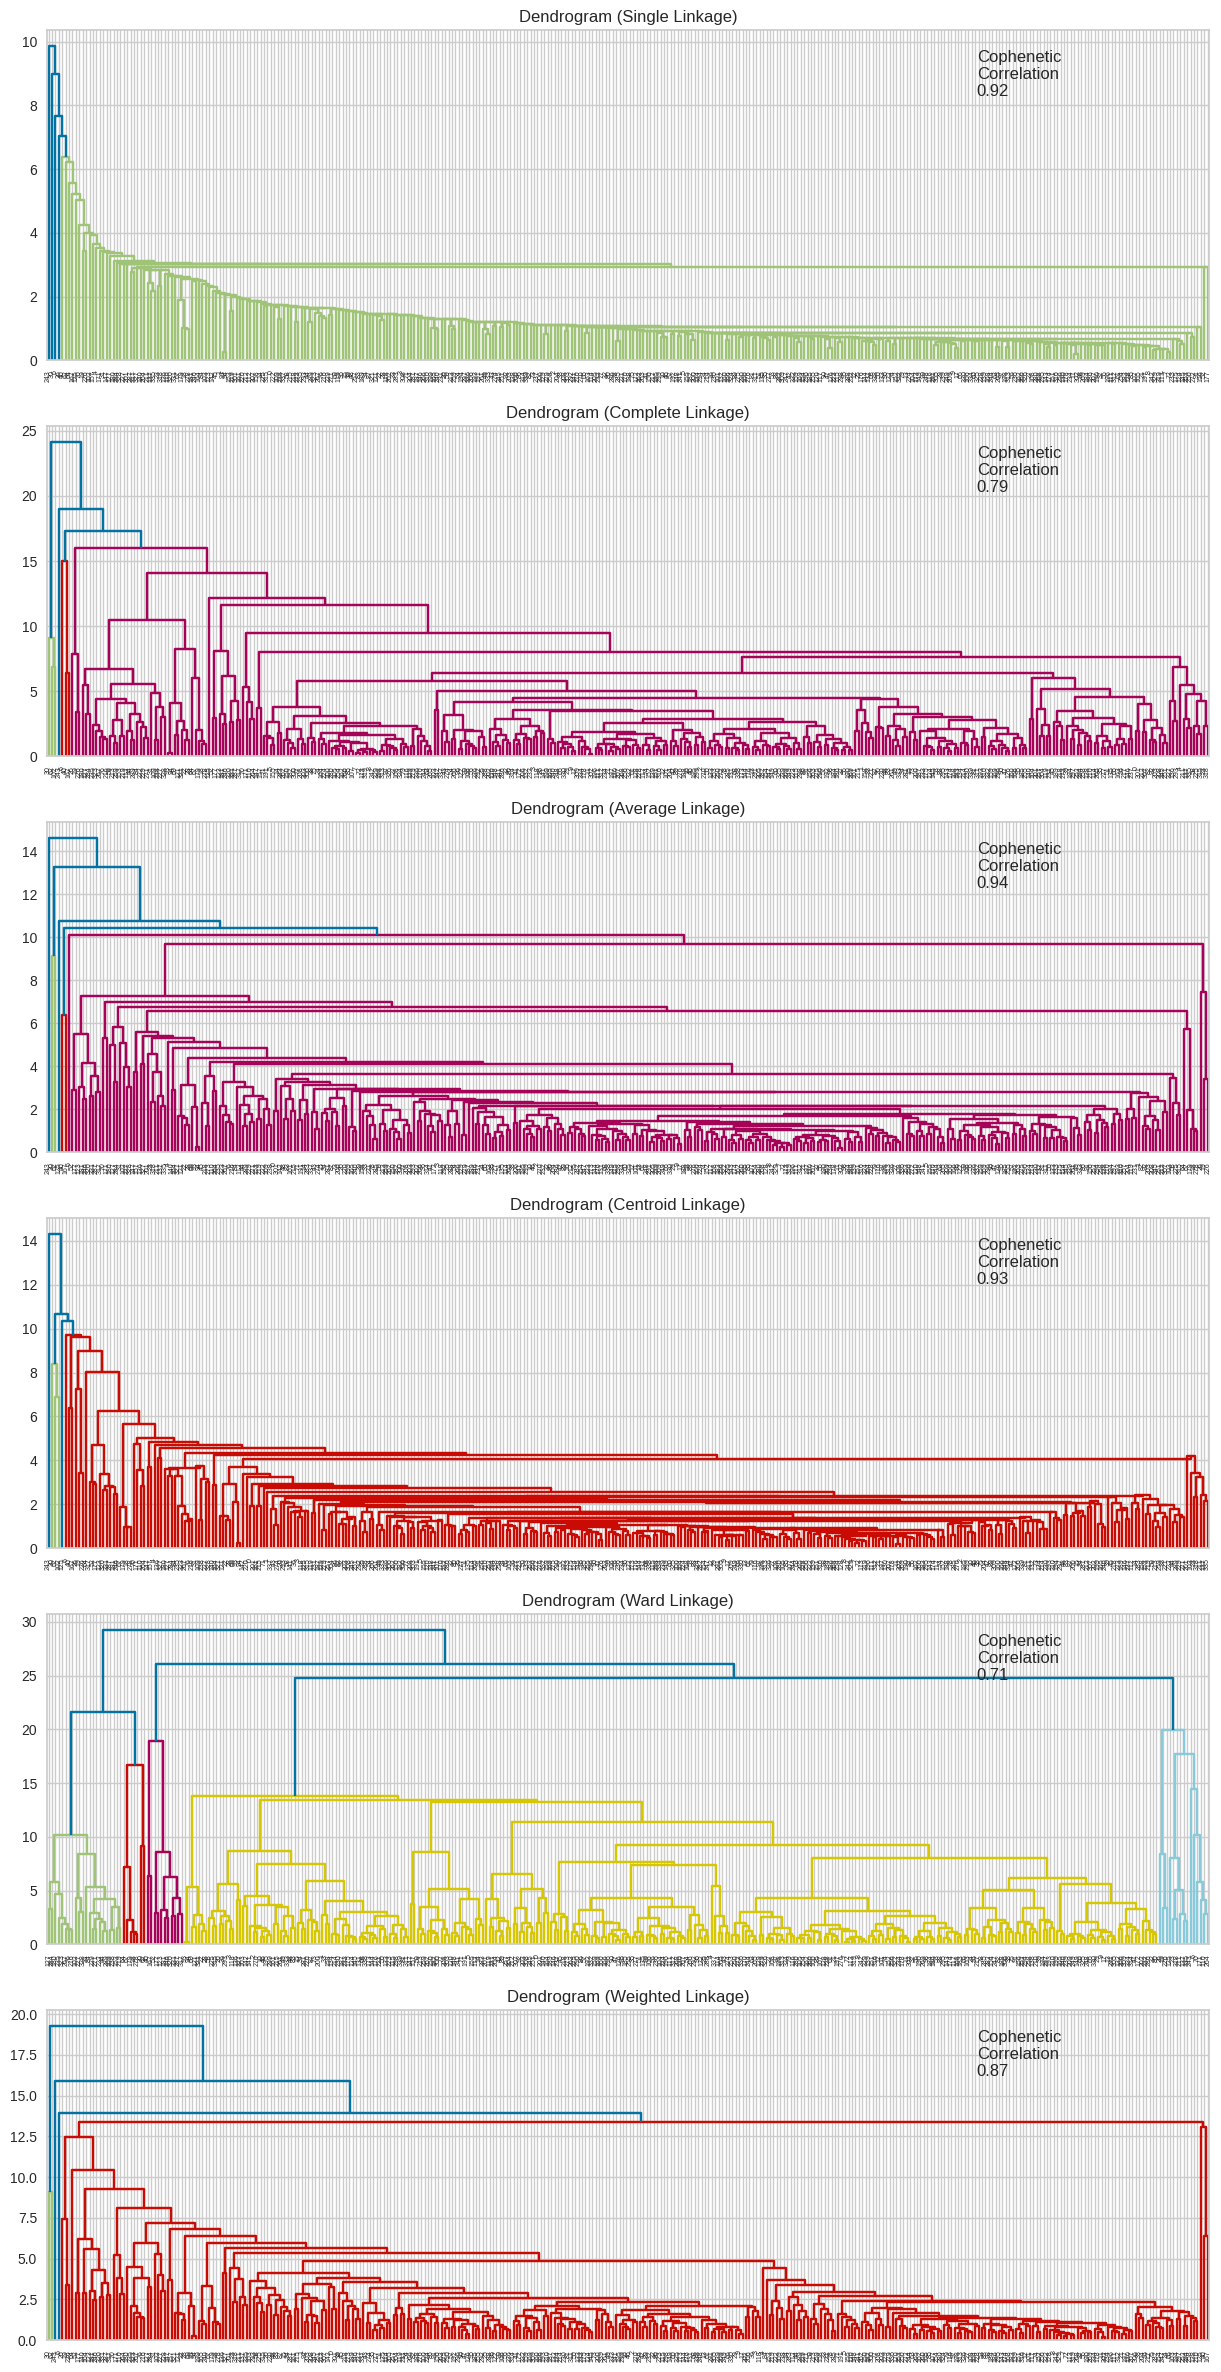

In [ ]:
%%time
# list of linkage methods
linkage_methods = ["single", "complete", "average", "centroid", "ward", "weighted"]

# lists to save results of cophenetic correlation calculation
compare_cols = ["Linkage", "Cophenetic Coefficient"]
compare = []

# to create a subplot image
fig, axs = plt.subplots(len(linkage_methods), 1, figsize=(15, 30))

# We will enumerate through the list of linkage methods above
# For each linkage method, we will plot the dendrogram and calculate the cophenetic correlation
for i, method in enumerate(linkage_methods):
    Z = linkage(hc_df, metric="euclidean", method=method)

    dendrogram(Z, ax=axs[i])
    axs[i].set_title(f"Dendrogram ({method.capitalize()} Linkage)")

    coph_corr, coph_dist = cophenet(Z, pdist(hc_df))
    axs[i].annotate(
        f"Cophenetic\nCorrelation\n{coph_corr:0.2f}",
        (0.80, 0.80),
        xycoords="axes fraction",
    )

    compare.append([method, coph_corr])

**Observations**

- Dendrogram for Ward linkage shows distinct and separate clusters.

In [ ]:
# creating and printing a dataframe to compare cophenetic correlations for different linkage methods
df_cc = pd.DataFrame(compare, columns=compare_cols)
df_cc = df_cc.sort_values(by="Cophenetic Coefficient")
df_cc

,Linkage,Cophenetic Coefficient
4,ward,0.710118
1,complete,0.787328
5,weighted,0.869378
0,single,0.923227
3,centroid,0.931401
2,average,0.942254


**Observation**

Average linkage method has the highest cophenetic coefficient (closest to 1) while Ward has the lowest.

Determining the number of clusters based on the **Average linkage** with the highest coefficient, Consider the sequence of heights at which clusters are merged when going from a small number of clusters to a larger number:

      1st set of clusters are formed when the last merge happens around a height of 15.
      2nd set of clusters are formed when the next split happens around a height of 12.5. (Difference from previous = 2.5)
      3rd set of clusters are formed when the next split happens around a height of 10. (Difference from previous = 2.5)
      4th set of clusters are formed when the next split happens around a height of 8. (Difference from previous = 2)
      5th set of clusters are formed when the next split happens around a height of 7. (Difference from previous = 1)
      6th set of clusters are formed when the next split happens around a height of 6. (Difference from previous = 1)

The differences in merge heights are **2.5, 2.5, 2, 1, 1**. The drop from a difference of 2 (when distinguishing 5 clusters) to a difference of 1 (when distinguishing 6 clusters) is notable. This suggests that after 5 clusters, the newly formed clusters are less distinct.

Therefore, **5 clusters** is a good choice based on the Average Linkage dendrogram.

Also the **Ward Linkage** dendrogram shows 5 distinct separate colored clusters, thus confirming 5 as the ideal and optimal clusters.

**Creating Final Hierarchial model for 5 clusters**

In [ ]:
%%time
# creating a model with 5 clusters
HCmodel = AgglomerativeClustering(n_clusters=5, metric="euclidean", linkage="ward")
HCmodel.fit(subset_scaled_df)

CPU times: user 9.51 ms, sys: 0 ns, total: 9.51 ms
Wall time: 10.4 ms


AgglomerativeClustering(n_clusters=5)

In [ ]:
%%time

# creating a copy of the original data
df2 = df.copy()

# adding hierarchical cluster labels to the original and scaled dataframes
hc_df["HC_segments"] = HCmodel.labels_
df2["HC_segments"] = HCmodel.labels_

CPU times: user 1.32 ms, sys: 791 µs, total: 2.11 ms
Wall time: 1.99 ms


## Cluster Profiling

In [ ]:
# Re-initialize num_cols to ensure it contains the correct numerical column names
num_cols2 = df2.select_dtypes(include=np.number).columns.tolist()

# Select only the numerical columns for cluster profiling from df2
numerical_df = df2[num_cols2].copy() # Select all numerical columns which now includes HC_segments

In [ ]:
%%time

# Calculate the mean for each cluster using only numerical columns
hc_cluster_profile = numerical_df.groupby("HC_segments").mean()

CPU times: user 2.62 ms, sys: 0 ns, total: 2.62 ms
Wall time: 2.57 ms


In [ ]:
%%time

# count of companies and group by the new HC_segments and assign it to count_in_each_segments
hc_cluster_profile["count_in_each_segment"] = (
    df2.groupby("HC_segments")["Security"].count().values
)

CPU times: user 1.92 ms, sys: 0 ns, total: 1.92 ms
Wall time: 1.94 ms


In [ ]:
%%time
# Displaying the cluster profiles
hc_cluster_profile.style.highlight_max(color="lightgreen", axis=0)

CPU times: user 234 µs, sys: 953 µs, total: 1.19 ms
Wall time: 941 µs


,Current_Price,Price_Change,Volatility,ROE,Cash_Ratio,Net_Cash_Flow,Net_Income,Earnings_Per_Share,Estimated_Shares_Outstanding,P/E_Ratio,P/B_Ratio,count_in_each_segment
HC_segments,,,,,,,,,,,,
0,326.198218,10.563242,1.642560,14.400000,309.466667,288850666.666667,864498533.333333,7.785333,544900261.301333,113.095334,19.142151,15
1,84.355716,3.854981,1.827670,633.571429,33.571429,-568400000.000000,-4968157142.857142,-10.841429,398169036.442857,42.284541,-11.589502,7
2,42.848182,6.270446,1.123547,22.727273,71.454545,558636363.636364,14631272727.272728,3.410000,4242572567.290909,15.242169,-4.924615,11
3,72.760400,5.213307,1.427078,25.603509,60.392982,79951512.280702,1538594322.807018,3.655351,446472132.228456,24.722670,-2.647194,285
4,36.440455,-16.073408,2.832884,57.500000,42.409091,-472834090.909091,-3161045227.272727,-8.005000,514367806.201818,85.555682,0.836839,22


In [ ]:
## Printing the companies in each cluster
for cl in df2["HC_segments"].unique():
    print("In cluster {}, the following companies are present:".format(cl))
    print(df2[df2["HC_segments"] == cl]["Security"].unique())
    print()

In cluster 3, the following companies are present:
['American Airlines Group' 'AbbVie' 'Abbott Laboratories'
 'Adobe Systems Inc' 'Analog Devices, Inc.' 'Archer-Daniels-Midland Co'
 'Ameren Corp' 'American Electric Power' 'AFLAC Inc'
 'American International Group, Inc.' 'Apartment Investment & Mgmt'
 'Assurant Inc' 'Arthur J. Gallagher & Co.' 'Akamai Technologies Inc'
 'Albemarle Corp' 'Alaska Air Group Inc' 'Allstate Corp'
 'Applied Materials Inc' 'AMETEK Inc' 'Affiliated Managers Group Inc'
 'Ameriprise Financial' 'American Tower Corp A' 'AutoNation Inc'
 'Anthem Inc.' 'Aon plc' 'Amphenol Corp' 'Arconic Inc'
 'Activision Blizzard' 'AvalonBay Communities, Inc.' 'Broadcom'
 'American Water Works Company Inc' 'American Express Co' 'Boeing Company'
 'Baxter International Inc.' 'BB&T Corporation' 'Bard (C.R.) Inc.'
 'BIOGEN IDEC Inc.' 'The Bank of New York Mellon Corp.' 'Ball Corp'
 'Bristol-Myers Squibb' 'Boston Scientific' 'BorgWarner'
 'Boston Properties' 'Caterpillar Inc.' 'Chubb Lim

In [ ]:
# check the counts by GICS Sector for every clusters
df2.groupby(["HC_segments", "GICS_Sector"])['Security'].count()

HC_segments  GICS_Sector                
0            Consumer Discretionary          3
             Consumer Staples                1
             Health Care                     5
             Information Technology          4
             Real Estate                     1
             Telecommunications Services     1
1            Consumer Discretionary          1
             Consumer Staples                2
             Energy                          2
             Financials                      1
             Industrials                     1
2            Consumer Discretionary          1
             Consumer Staples                1
             Energy                          1
             Financials                      4
             Health Care                     1
             Information Technology          1
             Telecommunications Services     2
3            Consumer Discretionary         35
             Consumer Staples               15
             Energy                          7
             Financials                     44
             Health Care                    34
             Industrials                    52
             Information Technology         27
             Materials                      19
             Real Estate                    26
             Telecommunications Services     2
             Utilities                      24
4            Energy                         20
             Information Technology          1
             Materials                       1
Name: Security, dtype: int64

CPU times: user 1.56 s, sys: 21.6 ms, total: 1.58 s
Wall time: 1.63 s


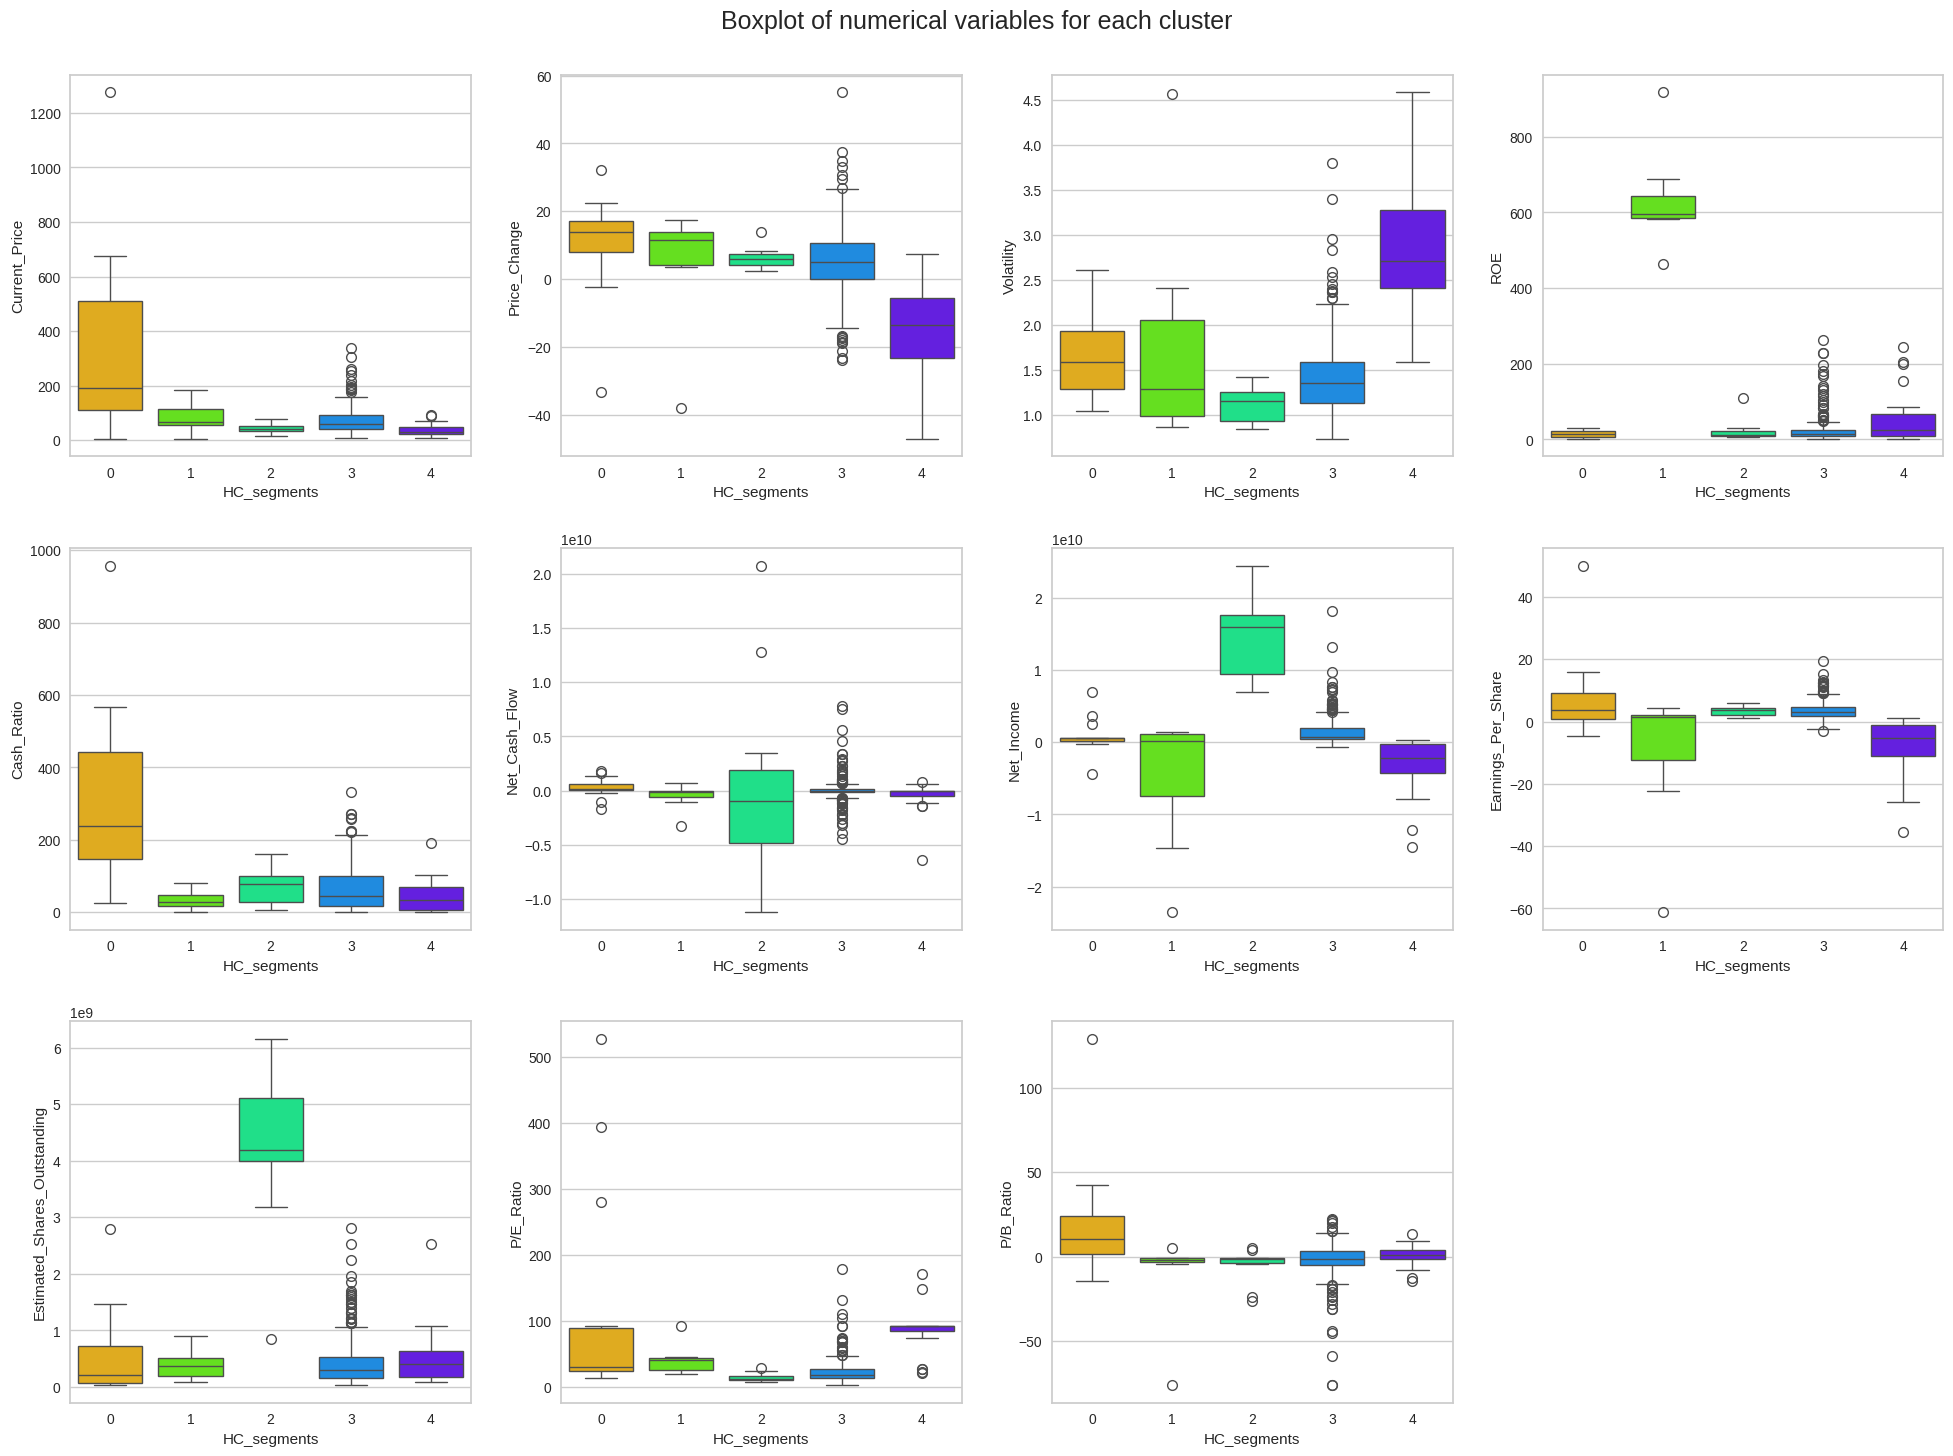

In [ ]:
%%time
# Visualizing the distribution of the numerical variables within each HC_segment cluster
plt.figure(figsize=(20, 15))
plt.suptitle("Boxplot of numerical variables for each cluster", fontsize = 18)

for i, variable in enumerate(num_cols):
    plt.subplot(3, 4, i + 1)
    sns.boxplot(data=df2, x="HC_segments", y=variable, palette="gist_rainbow")

plt.tight_layout(pad=2.0);

## Insights and Observations

**Cluster 0 (Orange)**: Characterized by higher current prices, significant liquidity (**high cash ratio**), and premium valuations (**high PE and PB ratios**), but also a general decline in price. This segment might represent established, potentially mature or overvalued, entities.

**Cluster 1 (Green)**: Appears to represent high-performing entities with strong profitability (**high ROE but low Net Income and EPS**), positive price changes, and relatively stable low volatility. They also tend to have lower Current prices compared to Segment 0, suggesting turnaround or leveraged firms.

**Cluster 2 (Light Green)**: Distinctive for having a significantly higher **Net income and ESO with good EPS**. While generally showing lower prices and financial ratios compared to Segment 1, they appear more stable indicating large, profitable companies.

**Cluster 3 (Turquoise)**: Exhibits the low volatility and a stable spread in profitability metrics (**net cash flow, net income, earnings per share**). This segment could represent stable and conservative entities.

**Cluster 4 (Purple)**: Generally shows lower values across most financial metrics (**ROE, Net Income, Earnings Per Share, Cash Ratio, Price Change**) with high **Volatility**. This segment might represent risky or underperforming or less liquid entities.

## Cluster Overlap or Similarity between K-Means and Hierarchical Clusters

To evaluate how similar the clustering results from K-Means and Hierarchical Clustering using Use Adjusted Rand Index (ARI) or Normalized Mutual Information (NMI) from sklearn.metrics.

A score close to 1 indicates high overlap in assignments between both techniques.

In [ ]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

# To measure overlap between K-Means and Hierarchical clusters:
ari = adjusted_rand_score(kmeans.labels_, HCmodel.labels_)
nmi = normalized_mutual_info_score(kmeans.labels_, HCmodel.labels_)

print("Adjusted Rand Index:", ari)
print("Normalized Mutual Information:", nmi)


Adjusted Rand Index: 0.7454278504817596
Normalized Mutual Information: 0.6588375552289072


### Observations

The two algorithms (K-Means and Hierarchical) are producing consistently similar clusters, though not identical.

**Adjusted Rand Index (ARI)** = 0.745 shows strong alignment in actual cluster membership. Around 75% of the clustering decisions align, accounting for randomness.

**Normalized Mutual Information (NMI)** = 0.659 shows moderate agreement in structural clustering information. About 66% of the clustering structure overlaps in terms of information content

## K-means vs Hierarchical Clustering

You compare several things, like:
- Which clustering technique took less time for execution?
- Which clustering technique gave you more distinct clusters, or are they the same?
- How many observations are there in the similar clusters of both algorithms?
- How many clusters are obtained as the appropriate number of clusters from both algorithms?

You can also mention any differences or similarities you obtained in the cluster profiles from both the clustering techniques.

**Execution**: Although K-Means generally take less time to execute than Hierarchical clusters, for this project, no significant difference was observed. Although it took 2.86 seconds to view the Dendrograms for the hierarchical clusters compared to the 361 ms it took to visualize the silhouette of the K-Means, the final model took 7.83 seconds for the K-Means and 7.65 seconds for the HC clusters, respectively.

**Distinct Clusters**: K-Means Clustering produced more distinct clusters overall.
   - It shows better separation across a broader range of variables, especially in valuation metrics like P/E, P/B, and shares outstanding.

   - Hierarchical clustering does well on ROE and liquidity, but generally has more overlapping distributions.

**Observations in the similar Clusters**: Since the dataset used for clustering contains **340 observations (samples)** and the **Adjusted Rand Index (ARI)is 0.745** , this tells us that about 74.5% of both clustering algorithms are in agreement.
Therefore,
- **Number of similar observations** in both clustering algorithms = 0.745 * 340 = 253.


**Number of Clusters from both algorithms**: five (5) clusters each were obtained from algorithms.

## Dimensionality Reduction using PCA for visualization

Using a scree plot to understand how many components are needed for the PCA analysis.

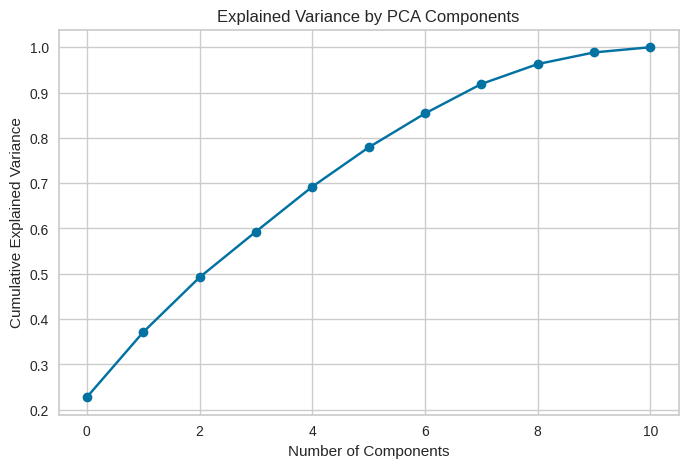

In [ ]:
# Scree plot to understand how many components are needed for a good representation

# Fit PCA with all components
pca = PCA()
pca.fit(subset_scaled_df)

# Plot cumulative explained variance
plt.figure(figsize=(8, 5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance by PCA Components')
plt.grid(True)
plt.show()


1. Optimal Number of Components (Dimensionality Reduction):
The "elbow point" (where the curve starts to bend) is around 4–5 components.

This suggests that 5 components may be optimal — they capture a large amount of the variance while avoiding redundancy.

2. Explained Variance:
First 4 components: Rapid gain in variance.

After 5: Diminishing returns begin — the additional variance explained becomes marginal.

After 6–7: Very small gains (~0.06 to 0.08), suggesting noise or redundant information.

3. Cumulative Variance Insight: the idea is to choose the number of components that explain at least 90% or 95% of the variance.

   - 5 components explain ~77% of the total variance.

   - 6 components: ~85%

   - 7 components: ~91%

   - 8 components: ~96%

This indicates most of the structure in the dataset is captured within the first 6–8 components.

However, based on the "**elbow rule**," where the bend in the curve becomes less steep and for the sake of efficient clusters and more preserved information, it's best to lean towards 6-7 components that explains ~ 91%.

In [ ]:
# getting the PCA of the scaled data, using 7 components of the above 7X7 covariant matrix
pca = PCA(n_components=7)
pca.fit(subset_scaled_df)

PCA(n_components=7)

In [ ]:
# getting the PCA eigen vector component that represents the eigen vectors
print(pca.components_)
print("---" * 30)
print("This is the full 7x7 matrix")

[[ 0.18335823  0.27666842 -0.42919618 -0.30106508  0.08417114  0.03368814
   0.51091003  0.5033668   0.22120756 -0.20815091  0.00991673]
 [ 0.5774047   0.18815749  0.04101083 -0.06258117  0.32773726  0.1280034
  -0.25155831  0.18433241 -0.36327549  0.37736302  0.360796  ]
 [-0.17770732  0.04646452  0.18283759  0.00473711  0.53919175  0.1855024
   0.20918754 -0.27531285  0.58166569  0.24934832  0.2959799 ]
 [-0.00900284  0.65971773 -0.38664453  0.53431652  0.0838151  -0.13655589
  -0.12101272 -0.26011429  0.02333621 -0.00303257 -0.14551133]
 [-0.39287414  0.12202474 -0.14571667 -0.12446023  0.1588855   0.56275703
  -0.17221048 -0.06902206 -0.32807051 -0.47228787  0.29493986]
 [ 0.04539895  0.07374983 -0.01301984 -0.04924358 -0.1433002   0.69439441
   0.07660902 -0.02703535  0.00607268  0.39241333 -0.571456  ]
 [ 0.34597383 -0.32918961  0.06740711  0.69551664 -0.04384053  0.31995867
   0.15598116  0.16995766  0.13220581 -0.30317218  0.12940702]]
------------------------------------------

In [ ]:
# getting the PCA eigen values (distances)
print(pca.explained_variance_)

[2.51212401 1.58411327 1.33434149 1.11310406 1.09308721 0.95662194
 0.82731447]


In [ ]:
# the percentage ratio of variation explained by each eigen Vector (i.e the amount of variance explained PCA eigen values)
print(pca.explained_variance_ratio_)
print(f"Total combined ratio is:", pca.explained_variance_ratio_.sum())

[0.22770322 0.14358674 0.120947   0.10089366 0.09907929 0.08670985
 0.0749892 ]
Total combined ratio is: 0.8539089520908185


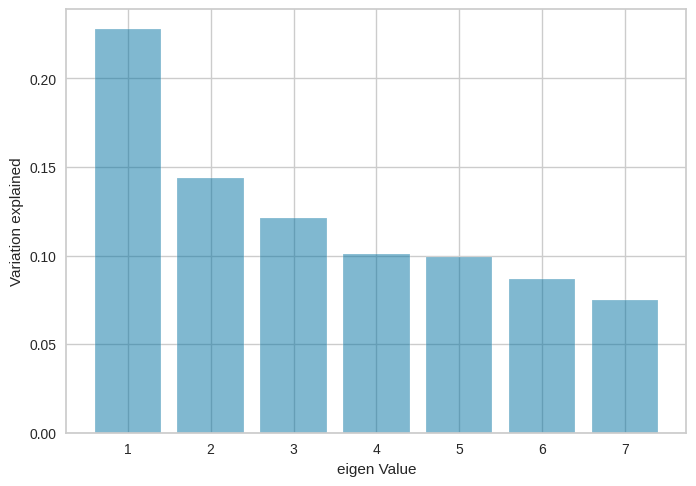

In [ ]:
# plot the percentage variation of the eigen values
plt.bar(list(range(1, 8)), pca.explained_variance_ratio_, alpha=0.5, align="center")
plt.ylabel("Variation explained")
plt.xlabel("eigen Value")
plt.show();

- The result shows that the 1st component explains ~23% of the data
- The 2nd and 3rd explain ~14% and 12% respectively.
- This implies that the 7 components combined can explain ~85% of the data.

In [ ]:
# setting the number of components to 7
# pca = PCA(n_components=7)

# Transforming data by reducing the numerical dimensions (from 11 to 7) representation of the original data and storing results in a dataframe
X_reduced_pca = pca.fit_transform(subset_scaled_df)
reduced_df_pca = pd.DataFrame(
    data=X_reduced_pca,
    columns=[
        "Component 1",
        "Component 2",
        "Component 3",
        "Component 4",
        "Component 5",
        "Component 6",
        "Component 7",
    ],
)

## Visualizing the KMeans labels and Hirarchial labels (cluster arrangments) based on the reduced PCA data

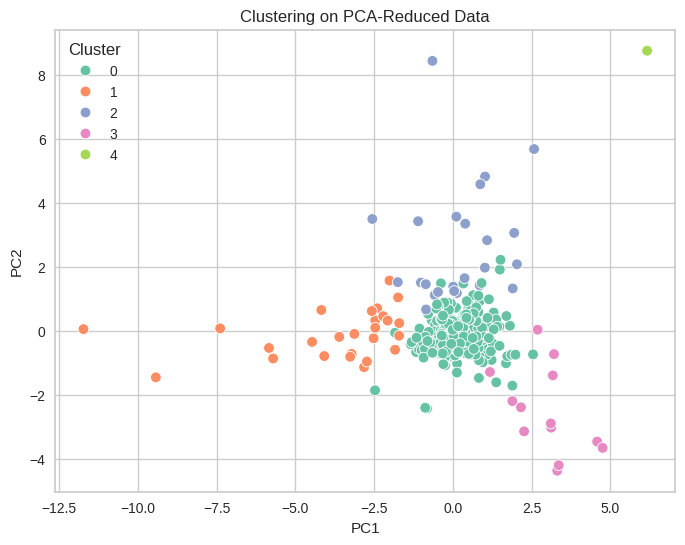

In [ ]:
# Combine labels for plotting using KMeans labels
plot_df = pd.DataFrame(X_reduced_pca[:, :2], columns=["PC1", "PC2"])
plot_df["Cluster"] = kmeans.labels_  # or hc_labels

# Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(data=plot_df, x="PC1", y="PC2", hue="Cluster", palette="Set2", s=60)
plt.title("Clustering on PCA-Reduced Data")
plt.show();

- cluster 0 is quite dense and centered around the origin (PC1 around 0 to 1, PC2 around 0 to 1). It seems to represent a large, central group of data points.
- Clusters 0, 2, and 3 appear relatively distinct from each other, although there's some overlap, particularly between Cluster 0 and the edges of Clusters 2 and 3.
- Cluster 1 is quite spread and overlaps with Cluster 0 on its right side.
- Cluster 4 is very clearly separated, possibly containing only a few points suggesting it might represent outliers or a very unique group.

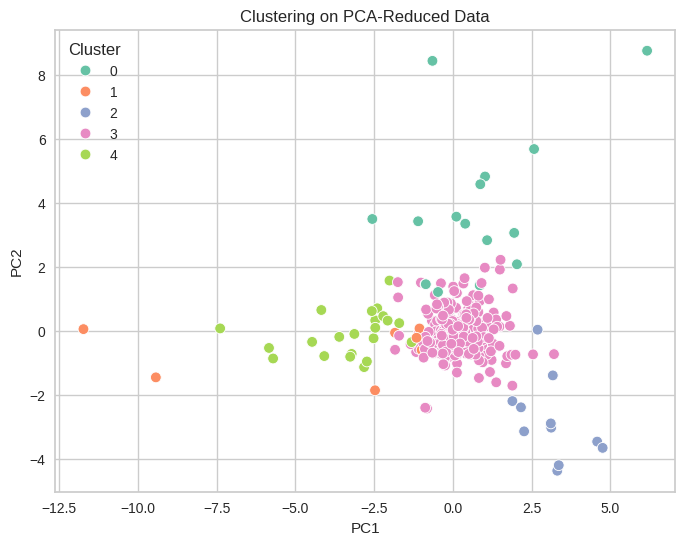

In [ ]:
# visualizing the components using HC labels
plot_df = pd.DataFrame(X_reduced_pca[:, :2], columns=["PC1", "PC2"])
plot_df["Cluster"] = HCmodel.labels_

# Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(data=plot_df, x="PC1", y="PC2", hue="Cluster", palette="Set2", s=60)
plt.title("Clustering on PCA-Reduced Data")
plt.show();

- Here, most of cluster 0 is somewhat separated from the rest if we draw a line at y = 1.
- Cluster 0 is more dense.

In [ ]:
# accessing the column name of the original scaled data
original_feature_names = subset_scaled_df2.columns

In [ ]:
subset_scaled_df2.head()

,Current_Price,Price_Change,Volatility,ROE,Cash_Ratio,Net_Cash_Flow,Net_Income,Earnings_Per_Share,Estimated_Shares_Outstanding,P/E_Ratio,P/B_Ratio
0,-0.393341,0.493950,0.272749,0.989601,-0.210698,-0.339355,1.554415,1.309399,0.107863,-0.652487,-0.506653
1,-0.220837,0.355439,1.137045,0.937737,0.077269,-0.002335,0.927628,0.056755,1.250274,-0.311769,-0.504205
2,-0.367195,0.602479,-0.427007,-0.192905,-0.033488,0.454058,0.744371,0.024831,1.098021,-0.391502,0.094941
3,0.133567,0.825696,-0.284802,-0.317379,1.218059,-0.152497,-0.219816,-0.230563,-0.091622,0.947148,0.424333
4,-0.260874,-0.492636,0.296470,-0.265515,2.237018,0.133564,-0.202703,-0.374982,1.978399,3.293307,0.199196


In [ ]:

# how much each original feature contributes to each principal component.
# how much each original feature contributes to each principal component.
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(pca.n_components_)],
    index=original_feature_names
)
# Show the top 7 contributing dimensions of the DataFrame
loadings  # or just `loadings` on the last line


,PC1,PC2,PC3,PC4,PC5,PC6,PC7
Current_Price,0.183358,0.577405,-0.177707,-0.009003,-0.392874,0.045399,0.345974
Price_Change,0.276668,0.188157,0.046465,0.659718,0.122025,0.073750,-0.329190
Volatility,-0.429196,0.041011,0.182838,-0.386645,-0.145717,-0.013020,0.067407
ROE,-0.301065,-0.062581,0.004737,0.534317,-0.124460,-0.049244,0.695517
Cash_Ratio,0.084171,0.327737,0.539192,0.083815,0.158886,-0.143300,-0.043841
Net_Cash_Flow,0.033688,0.128003,0.185502,-0.136556,0.562757,0.694394,0.319959
Net_Income,0.510910,-0.251558,0.209188,-0.121013,-0.172210,0.076609,0.155981
Earnings_Per_Share,0.503367,0.184332,-0.275313,-0.260114,-0.069022,-0.027035,0.169958
Estimated_Shares_Outstanding,0.221208,-0.363275,0.581666,0.023336,-0.328071,0.006073,0.132206
P/E_Ratio,-0.208151,0.377363,0.249348,-0.003033,-0.472288,0.392413,-0.303172


In [ ]:
# Get feature contributions to each PC
loadings = pd.DataFrame(
    pca.components_.T,  # transpose so rows = features, columns = components
    columns=[f'PC{i+1}' for i in range(7)],
    index=num_cols
)

loadings

,PC1,PC2,PC3,PC4,PC5,PC6,PC7
Current_Price,0.183358,0.577405,-0.177707,-0.009003,-0.392874,0.045399,0.345974
Price_Change,0.276668,0.188157,0.046465,0.659718,0.122025,0.073750,-0.329190
Volatility,-0.429196,0.041011,0.182838,-0.386645,-0.145717,-0.013020,0.067407
ROE,-0.301065,-0.062581,0.004737,0.534317,-0.124460,-0.049244,0.695517
Cash_Ratio,0.084171,0.327737,0.539192,0.083815,0.158886,-0.143300,-0.043841
Net_Cash_Flow,0.033688,0.128003,0.185502,-0.136556,0.562757,0.694394,0.319959
Net_Income,0.510910,-0.251558,0.209188,-0.121013,-0.172210,0.076609,0.155981
Earnings_Per_Share,0.503367,0.184332,-0.275313,-0.260114,-0.069022,-0.027035,0.169958
Estimated_Shares_Outstanding,0.221208,-0.363275,0.581666,0.023336,-0.328071,0.006073,0.132206
P/E_Ratio,-0.208151,0.377363,0.249348,-0.003033,-0.472288,0.392413,-0.303172


In [ ]:
# Top 3 contributing features per PC
top_features = {}
for pc in loadings.columns:
    top_features[pc] = loadings[pc].abs().sort_values(ascending=False).head(3).index.tolist()

pd.DataFrame(top_features)

,PC1,PC2,PC3,PC4,PC5,PC6,PC7
0,Net_Income,Current_Price,Estimated_Shares_Outstanding,Price_Change,Net_Cash_Flow,Net_Cash_Flow,ROE
1,Earnings_Per_Share,P/E_Ratio,Cash_Ratio,ROE,P/E_Ratio,P/B_Ratio,Current_Price
2,Volatility,Estimated_Shares_Outstanding,P/B_Ratio,Volatility,Current_Price,P/E_Ratio,Price_Change


## Actionable Insights and Recommendations

-